(05-31-portfolio-choice)=

# Parametrische portefeuilles en idiosyncratisch risico

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 2001–2016, van Campbell-Lettau-Malkiel-Xu tot de common
idiosyncratic volatility factor.

**Wat we al weten.** Markowitz gaf een exacte theorie van keuze, maar de
optimale portefeuille geschat uit steekproefgemiddelden verloor van 1/N
([](#01-04-markowitz)); Merton maakte het probleem dynamisch, en de hedgevraag
bleek te hangen aan een helling met een $t$-waarde rond één
([](#03-10-merton-icapm)). Tegelijk stapelden de feiten zich op: size, waarde
en momentum in de cross-sectie ([](#04-19-momentum)), voorspellers van het
marktrendement in de tijdreeks ([](#04-20-voorspelbaarheid)), en in
[](#05-30-wisselkoersen) dezelfde carry-, momentum- en value-signalen in valuta.

**Welke vraag staat open.** Hoe bouwt een belegger een portefeuille op feiten
die hij slecht kan meten, zonder dat de optimalisator de schattingsfout
uitvergroot — en welk risico telt daarbij eigenlijk mee?
```

## Overzicht

Rond de eeuwwisseling zat de portefeuilletheorie klem. De theorie van
[](#01-04-markowitz) en [](#03-10-merton-icapm) vroeg om verwachte rendementen en
covarianties van *alle* activa, eventueel per toestand van de economie; de empirie van
Deel IV zei dat verwachte rendementen samenhangen met een handvol eigenschappen en een
handvol voorspellers. Wie het eerste letterlijk nam, schatte duizenden gemiddelden en
kreeg ruis; wie het tweede nam, sorteerde portefeuilles zonder te weten hoeveel hij van
elke sortering moest kopen.

Pedro Santa-Clara schreef met Michael Brandt en Rossen Valkanov twee artikelen
die die klem oplosten door het probleem anders te *parameteriseren*. In
{cite:t}`BrandtSantaClara2006` wordt een dynamisch portefeuilleprobleem een
statisch mean-variance-probleem: voeg aan de activa "managed portfolios" toe
(het activum geschaald met een conditioneringsvariabele) en kies daarover één
keer een vaste mix. In {cite:t}`BrandtSantaClaraValkanov2009` gebeurt hetzelfde
in de cross-sectie: het gewicht van een aandeel is het marktgewicht plus een
lineaire functie van zijn gestandaardiseerde karakteristieken, en de drie
coëfficiënten van die functie worden rechtstreeks geschat door het gerealiseerde
nut van de belegger te maximaliseren. Duizend activa, drie parameters — in Santa-Clara's woorden een
poging "to rescue portfolio choice from the curse of dimensionality"
{cite}`SantaClara2026`. De vraag verschuift van "wat zijn de verwachte rendementen?" naar
"welke regel voor gewichten had het best gewerkt?", en daarmee wordt de schattingsfout van
Markowitz niet opgelost maar ingedamd.

Het tweede spoor is een feit op zoek naar een theorie.
{cite:t}`GoyalSantaClara2003` vonden dat de gemiddelde variantie van individuele
aandelen — grotendeels idiosyncratisch — het marktrendement voorspelt en de
marktvariantie niet: een botsing met [](#02-08-capm), waar idiosyncratisch risico
gratis weg te diversifiëren is. Het resultaat overleefde latere steekproeven niet
{cite}`BaliCakiciYanZhang2005,WeiZhang2005`, maar het vraagstuk bleef:
idiosyncratische volatiliteit steeg decennialang {cite}`CampbellLettauMalkielXu2001`,
aandelen met hoge idiosyncratische volatiliteit rendeerden slecht
{cite}`AngHodrickXingZhang2006`, en die volatiliteit heeft een sterke gemeenschappelijke
factor {cite}`HerskovicKellyLustigVanNieuwerburgh2016`. Epistemisch zitten we middenin
motief 3: de parametrische portefeuille gebruikt feiten zonder ze te verklaren, en de
volatiliteitsfeiten hebben meer concurrerende theorieën dan data.

We repliceren aan het eind de parametrische policy van Brandt, Santa-Clara en
Valkanov op de 100 size/BM-portefeuilles en de 25 size-momentumportefeuilles van
French, de managed-portfolio-aanpak op de markt met de dividendopbrengst en de
term spread, en de regressie van Goyal en Santa-Clara met de gemiddelde variantie
van 49 industrieportefeuilles.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, signal

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

## Intuïtie: waarom zou dit waar zijn?

Neem een belegger die gelooft dat kleine, goedkope aandelen met een goed afgelopen
jaar beter renderen. De Markowitz-route vraagt hem een verwacht rendement voor elk van
duizenden aandelen en een covariantiematrix van een miljoen elementen, en voert die in
een optimalisator die precies de slechtst geschatte richtingen opzoekt. De route van
Brandt, Santa-Clara en Valkanov vraagt alleen *hoeveel* hij van de markt wil afwijken
per eenheid "klein", "goedkoop" en "goed jaar". Dat zijn drie getallen, geschat uit alle
aandelen tegelijk, zodat de bedrijfsspecifieke ruis grotendeels wegmiddelt voordat de
schatter hem ziet.

Er zit een tweede gedachte in. De regel "marktgewicht plus $\theta$ maal
karakteristiek" betekent: houd de markt, plus $\theta$ eenheden van een
long-short-portefeuille die long gaat in aandelen met een hoge karakteristiek en short
in aandelen met een lage. Een parametrische policy kiest dus tussen een paar
*portefeuilles*, niet tussen duizenden *aandelen*. Dezelfde truc werkt in de tijd: wie
meer aandelen houdt als de dividendopbrengst hoog is, houdt een vaste positie in de
markt en in "de markt geschaald met de dividendopbrengst", en dat laatste is gewoon een
activum met een rendementsreeks. Het dynamische probleem van Merton wordt een statisch
probleem van Markowitz, met meer activa.

Dat helpt tegen schattingsfout omdat de parameterisatie een sterke prior oplegt: twee
aandelen met dezelfde karakteristieken krijgen hetzelfde gewicht, wat hun historische
gemiddelde ook was. Het is dezelfde reden dat 1/N wint van mean-variance; de
parametrische portefeuille zit tussen de twee in.

Goyal en Santa-Clara stelden een oudere vraag: welk risico telt? Voor een
gediversifieerde belegger alleen bèta. Maar de meeste huishoudens houden een handvol
aandelen, en voor hen is idiosyncratisch risico gewoon risico; stijgt de gemiddelde
onzekerheid over individuele bedrijven, dan eisen zij misschien een hogere premie op de
markt. Omdat het gemiddelde marktrendement slecht gemeten is en de gemiddelde variantie
zeer persistent, is een te zeker antwoord op die vraag gemakkelijk te krijgen.

## Toy-voorbeeld: een voorspeller met twee waarden, drie aandelen met één karakteristiek

### (a) Dynamisch wordt statisch

Eén risicovol activum met excess rendement $r_{t+1}$ en één voorspeller die twee
waarden aanneemt, elk met kans $\tfrac12$: laag ($x_t = -1$) en hoog ($x_t = +1$).
Gegeven laag is $\E[r_{t+1} \mid x_t] = 2\%$, gegeven hoog $10\%$; de conditionele
variantie is in beide toestanden $\sigma^2 = 0{,}04$. De belegger maximaliseert
het verwachte kwadratische nut $\E[w_t r_{t+1} - \tfrac{\gamma}{2}(w_t r_{t+1})^2]$
met $\gamma = 5$. Schrijf $s(x) = \E[r_{t+1}^2 \mid x] = \sigma^2 + \mu(x)^2$, dus
$s_{\text{laag}} = 0{,}0404$ en $s_{\text{hoog}} = 0{,}05$.

**Conditioneel.** In elke toestand apart is de optimale positie
$w(x) = \mu(x)/(\gamma s(x))$:
$w_{\text{laag}} = 0{,}02/(5 \cdot 0{,}0404) = 0{,}09901$ en
$w_{\text{hoog}} = 0{,}10/(5 \cdot 0{,}05) = 0{,}40$.

**Statisch, met een managed activum.** Definieer het tweede "activum"
$x_t r_{t+1}$: het rendement van een strategie die in de hoge toestand één
eenheid long en in de lage toestand één eenheid short gaat. Nu kiest de belegger
één keer een vaste mix $\theta = (\theta_0, \theta_1)$ van de twee betalingen
$\tilde{\mathbf{R}}_{t+1} = (r_{t+1},\, x_t r_{t+1})'$. Hun momenten:

$$
\E[\tilde{\mathbf{R}}] = \begin{pmatrix} \tfrac12(0{,}02 + 0{,}10) \\ \tfrac12(0{,}10 - 0{,}02)\end{pmatrix}
= \begin{pmatrix} 0{,}06 \\ 0{,}04 \end{pmatrix},
\qquad
\E[\tilde{\mathbf{R}}\tilde{\mathbf{R}}'] =
\begin{pmatrix} 0{,}0452 & 0{,}0048 \\ 0{,}0048 & 0{,}0452 \end{pmatrix},
$$

want $\E[r^2] = \tfrac12(0{,}0404 + 0{,}05)$, $\E[x r^2] = \tfrac12(0{,}05 - 0{,}0404)$
en $x^2 = 1$. De determinant is $0{,}0452^2 - 0{,}0048^2 = 0{,}00202$, en het
statische optimum $\theta = \gamma^{-1}\E[\tilde{\mathbf{R}}\tilde{\mathbf{R}}']^{-1}\E[\tilde{\mathbf{R}}]$ is

$$
\theta = \frac{1}{5 \cdot 0{,}00202}
\begin{pmatrix} 0{,}0452 \cdot 0{,}06 - 0{,}0048 \cdot 0{,}04 \\ -0{,}0048 \cdot 0{,}06 + 0{,}0452 \cdot 0{,}04 \end{pmatrix}
= \frac{1}{0{,}0101}\begin{pmatrix} 0{,}00252 \\ 0{,}00152\end{pmatrix}
= \begin{pmatrix} 0{,}24950 \\ 0{,}15050 \end{pmatrix}.
$$

De policy die daarbij hoort, is $w_t = \theta_0 + \theta_1 x_t$: in de lage toestand
$0{,}24950 - 0{,}15050 = 0{,}09901$ en in de hoge $0{,}24950 + 0{,}15050 = 0{,}40$.
Precies de conditionele oplossing: een vaste mix van twee rendementsreeksen doet exact
wat de conditioneel optimaliserende belegger doet.

Wat levert het op? Het verwachte nut van de conditionele strategie is
$\sum_x \tfrac12\,\mu(x)^2/(2\gamma s(x)) = \tfrac12(0{,}00099 + 0{,}02) = 0{,}010495$;
wie de voorspeller negeert en één vaste positie $\E[r]/(\gamma\E[r^2]) = 0{,}2655$
kiest, haalt $\E[r]^2/(2\gamma\E[r^2]) = 0{,}0036/0{,}452 = 0{,}007965$. Het managed
activum is een kwart van het verwachte nut waard.

In [2]:
gamma = 5.0
prob = np.array([0.5, 0.5])
mu_state = np.array([0.02, 0.10])            # E[r | low], E[r | high]
x_state = np.array([-1.0, 1.0])
s_state = 0.04 + mu_state**2                 # E[r^2 | x]

w_conditional = mu_state / (gamma * s_state)
payoff = np.column_stack([np.ones(2), x_state])          # (r, x r) = payoff * r
mean_managed = (prob * mu_state) @ payoff
second_moment = (payoff.T * (prob * s_state)) @ payoff
theta_managed = np.linalg.solve(second_moment, mean_managed) / gamma

pd.DataFrame(
    {"conditioneel": w_conditional,
     "statisch: theta0 + theta1 x": theta_managed[0] + theta_managed[1] * x_state},
    index=["x = -1 (laag)", "x = +1 (hoog)"],
).round(5)

,conditioneel,statisch: theta0 + theta1 x
x = -1 (laag),0.09901,0.09901
x = +1 (hoog),0.40000,0.40000


In [3]:
ce_timing = prob @ (mu_state**2 / (2 * gamma * s_state))
ce_static = (prob @ mu_state) ** 2 / (2 * gamma * (prob @ s_state))
print(f"theta = {theta_managed.round(5)}   (hand: 0.24950, 0.15050)")
print(f"E[R~] = {mean_managed},  E[R~R~'] = {second_moment.ravel().round(4)}")
print(f"verwacht nut met timing {ce_timing:.6f}, zonder {ce_static:.6f}   (hand: 0.010495, 0.007965)")

theta = [0.2495 0.1505]   (hand: 0.24950, 0.15050)
E[R~] = [0.06 0.04],  E[R~R~'] = [0.0452 0.0048 0.0048 0.0452]
verwacht nut met timing 0.010495, zonder 0.007965   (hand: 0.010495, 0.007965)


### (b) Een parametrische policy met drie aandelen

Drie aandelen met marktgewichten $\bar{\mathbf{w}} = (0{,}5;\ 0{,}3;\ 0{,}2)$ en
één karakteristiek, het momentum van het afgelopen jaar: $-10\%$, $5\%$ en $20\%$.
Standaardiseer over de cross-sectie: het gemiddelde is $5\%$, de
standaarddeviatie $15\%$, dus $\hat{x} = (-1;\ 0;\ 1)$. De policy van Brandt,
Santa-Clara en Valkanov is

$$
w_i(\theta) = \bar w_i + \frac{\theta\, \hat{x}_i}{N},\qquad N = 3 .
$$

Omdat $\sum_i \hat{x}_i = 0$, telt elke $\mathbf{w}(\theta)$ op tot één. Bij
$\theta = 0$ is $\mathbf{w} = (0{,}5;\ 0{,}3;\ 0{,}2)$; bij $\theta = 1{,}5$ is
$\mathbf{w} = (0{,}5 - 0{,}5;\ 0{,}3;\ 0{,}2 + 0{,}5) = (0;\ 0{,}3;\ 0{,}7)$.

In de volgende periode renderen de aandelen $-3\%$, $1\%$ en $6\%$. Het
portefeuillerendement is bij $\theta = 0$ gelijk aan
$0{,}5(-0{,}03) + 0{,}3(0{,}01) + 0{,}2(0{,}06) = 0$, bij $\theta = 1{,}5$ gelijk aan
$0{,}3(0{,}01) + 0{,}7(0{,}06) = 4{,}5\%$. Met CRRA-nut $u(R) = R^{1-\gamma}/(1-\gamma)$
en $\gamma = 5$ is het gerealiseerde nut $u(1{,}000) = -0{,}25$ en
$u(1{,}045) = -1/(4 \cdot 1{,}045^4) = -1/(4 \cdot 1{,}19252) = -0{,}20964$.

Het portefeuillerendement is $R_p(\theta) = \bar R + \theta\, r^{x}$ met
$r^{x} = \tfrac1N \sum_i \hat{x}_i r_i = \tfrac13(0{,}03 + 0 + 0{,}06) = 3\%$: het
rendement van een long-short-*karakteristiekportefeuille*. Met één periode stijgt het nut
dus onbeperkt in $\theta$ zolang $r^x > 0$; pas meer perioden maken het probleem
interessant. Neem een tweede periode met dezelfde $\hat{x}$ en rendementen $4\%$, $1\%$ en
$-5\%$: dan is $\bar R = 1{,}3\%$ en $r^x = -3\%$, en het gemiddelde nut
$\tfrac12[u(1 + 0{,}03\theta) + u(1{,}013 - 0{,}03\theta)]$ is maximaal waar de twee
brutorendementen gelijk zijn, bij $\theta^{\ast} = 0{,}013/0{,}06 = 0{,}2167$.

In [4]:
w_bar = np.array([0.5, 0.3, 0.2])
momentum_raw = np.array([-0.10, 0.05, 0.20])
x_hat = (momentum_raw - momentum_raw.mean()) / momentum_raw.std(ddof=1)
returns_1 = np.array([-0.03, 0.01, 0.06])
returns_2 = np.array([0.04, 0.01, -0.05])


def toy_policy(theta):
    """BSV weights for the three-stock example."""
    return w_bar + theta * x_hat / len(x_hat)


def crra(R, g=5.0):
    return R ** (1 - g) / (1 - g)


rows = {th: {"w1": toy_policy(th)[0], "w2": toy_policy(th)[1], "w3": toy_policy(th)[2],
             "R_p": 1 + toy_policy(th) @ returns_1, "nut": crra(1 + toy_policy(th) @ returns_1)}
        for th in [0.0, 1.5]}
two_period = optimize.minimize_scalar(
    lambda th: -(crra(1 + toy_policy(th) @ returns_1) + crra(1 + toy_policy(th) @ returns_2)) / 2,
    bounds=(-5, 5), method="bounded")
print(f"x_hat = {np.round(x_hat, 4) + 0.0},  r^x = {x_hat @ returns_1 / 3:.4f}")
print(f"theta* over twee perioden = {two_period.x:.4f}   (hand: 0.013/0.06 = {0.013 / 0.06:.4f})")
pd.DataFrame(rows).T.rename_axis("theta").round(5)

x_hat = [-1.  0.  1.],  r^x = 0.0300
theta* over twee perioden = 0.2167   (hand: 0.013/0.06 = 0.2167)


,w1,w2,w3,R_p,nut
theta,,,,,
0.0,0.5,0.3,0.2,1.000,-0.25000
1.5,0.0,0.3,0.7,1.045,-0.20964


De code geeft $\hat{x} = (-1, 0, 1)$, de gewichten $(0; 0{,}3; 0{,}7)$, het nut
$-0{,}25$ en $-0{,}20964$ en $\theta^{\ast} = 0{,}2167$, zoals met de hand.

## Theorie

### Brandt en Santa-Clara: het dynamische probleem als statisch probleem

*Waarom zou dit waar zijn?* Een conditionele strategie die lineair is in wat de
belegger ziet, heeft als rendement een vaste combinatie van producten "signaal maal
rendement". Die producten zijn betalingen met schatbare momenten, net als aandelen, en
een vaste mix over vaste betalingen kiezen is Markowitz. De vraag is alleen of dat de
beste conditionele regel oplevert; het antwoord is ja zodra de regel rijk genoeg is.

Laat er $N$ risicovolle activa zijn met excess rendementen
$\mathbf{r}_{t+1} \in \mathbb{R}^N$, en een vector conditioneringsvariabelen
$\mathbf{x}_t \in \mathbb{R}^K$ die op $t$ bekend is (met een constante als eerste
element). Een lineaire policy is $\mathbf{w}_t = \boldsymbol{\Theta}\mathbf{x}_t$
met $\boldsymbol{\Theta} \in \mathbb{R}^{N\times K}$. Het portefeuillerendement is

```{math}
:label: eq-portfolio-choice-managed
\mathbf{w}_t'\mathbf{r}_{t+1} = \mathbf{x}_t'\boldsymbol{\Theta}'\mathbf{r}_{t+1}
= \boldsymbol{\theta}'\left(\mathbf{x}_t \otimes \mathbf{r}_{t+1}\right),
\qquad \boldsymbol{\theta} = \mathrm{vec}(\boldsymbol{\Theta}) ,
```

en $\tilde{\mathbf{R}}_{t+1} = \mathbf{x}_t \otimes \mathbf{r}_{t+1}$ is de vector
van $NK$ *managed portfolios* (activum $i$ geschaald met variabele $k$).
{cite:t}`BrandtSantaClara2006` schrijven het zo met een mean-variance-benadering
van het nut; wij gebruiken kwadratisch nut in het tweede moment, omdat de
equivalentie dan exact is.

:::{prf:proposition} Conditionele keuze als statische keuze (Brandt-Santa-Clara)
:label: thm-portfolio-choice-bsc

Laat de toestand $z_t$ waarden aannemen in $\{z^1, \dots, z^K\}$ met kansen
$p_k > 0$, en laat $\boldsymbol{\mu}_k = \E[\mathbf{r}_{t+1} \mid z_t = z^k]$ en
$\mathbf{S}_k = \E[\mathbf{r}_{t+1}\mathbf{r}_{t+1}' \mid z_t = z^k]$ positief
definiet. De belegger maximaliseert $\E[\mathbf{w}_t'\mathbf{r}_{t+1} -
\tfrac{\gamma}{2}(\mathbf{w}_t'\mathbf{r}_{t+1})^2]$.

1. De conditioneel optimale policy is $\mathbf{w}^{\ast}(z^k) = \gamma^{-1}\mathbf{S}_k^{-1}\boldsymbol{\mu}_k$.
2. Laat $\mathbf{x}_t = \mathbf{A}\,\mathbf{e}(z_t)$, met $\mathbf{e}(z^k)$ de $k$-de
   eenheidsvector en $\mathbf{A}$ een inverteerbare $K\times K$-matrix. Het statische
   probleem $\max_{\boldsymbol{\theta}} \E[\boldsymbol{\theta}'\tilde{\mathbf{R}}]
   - \tfrac{\gamma}{2}\E[(\boldsymbol{\theta}'\tilde{\mathbf{R}})^2]$ heeft de unieke oplossing
   ```{math}
   :label: eq-portfolio-choice-bsc-theta
   \boldsymbol{\theta}^{\ast} = \frac1\gamma\,\E\!\left[\tilde{\mathbf{R}}\tilde{\mathbf{R}}'\right]^{-1}\E\!\left[\tilde{\mathbf{R}}\right],
   ```
   en de bijbehorende policy $\boldsymbol{\Theta}^{\ast}\mathbf{x}_t$ is gelijk aan $\mathbf{w}^{\ast}(z_t)$
   in elke toestand.
3. Is $z_t$ continu en $\mathbf{x}_t = (1, z_t)'$, dan levert [](#eq-portfolio-choice-bsc-theta)
   de beste policy binnen de klasse van affiene policies.
:::

:::{prf:proof}
(1) Gegeven $z_t = z^k$ is het doel $\mathbf{w}'\boldsymbol{\mu}_k - \tfrac{\gamma}{2}\mathbf{w}'\mathbf{S}_k\mathbf{w}$,
strikt concaaf, met eerste-ordevoorwaarde $\boldsymbol{\mu}_k = \gamma\mathbf{S}_k\mathbf{w}$.

(2) Neem eerst $\mathbf{A} = \mathbf{I}$. Dan is $\boldsymbol{\theta}'\tilde{\mathbf{R}}_{t+1} = \boldsymbol{\theta}_k'\mathbf{r}_{t+1}$
in toestand $k$, met $\boldsymbol{\theta}_k$ het $k$-de blok van $\boldsymbol{\theta}$. Met de wet van
de herhaalde verwachtingen is het doel
$\sum_k p_k\big(\boldsymbol{\theta}_k'\boldsymbol{\mu}_k - \tfrac{\gamma}{2}\boldsymbol{\theta}_k'\mathbf{S}_k\boldsymbol{\theta}_k\big)$:
een som van $K$ problemen die elk alleen van hun eigen blok afhangen en elk door
(1) worden opgelost. Tegelijk is $\E[\tilde{\mathbf{R}}\tilde{\mathbf{R}}']$ blokdiagonaal
met blokken $p_k\mathbf{S}_k$ en $\E[\tilde{\mathbf{R}}]$ heeft blokken $p_k\boldsymbol{\mu}_k$, dus
[](#eq-portfolio-choice-bsc-theta) geeft blok voor blok $\gamma^{-1}\mathbf{S}_k^{-1}\boldsymbol{\mu}_k$.
Voor algemene $\mathbf{A}$ is $\tilde{\mathbf{R}}^{A} = (\mathbf{A}\otimes\mathbf{I})\tilde{\mathbf{R}}$;
de verzameling bereikbare rendementen $\{\boldsymbol{\theta}'\tilde{\mathbf{R}}^{A}\}$ is dezelfde,
dus ook het optimale rendement en de policy, met
$\boldsymbol{\theta}^{A} = (\mathbf{A}'\otimes\mathbf{I})^{-1}\boldsymbol{\theta}^{\ast}$.
Uniciteit volgt uit de positieve definietheid van $\E[\tilde{\mathbf{R}}\tilde{\mathbf{R}}']$.

(3) Elke affiene policy is van de vorm $\boldsymbol{\theta}'\tilde{\mathbf{R}}$ en het doel is
strikt concaaf in $\boldsymbol{\theta}$; [](#eq-portfolio-choice-bsc-theta) is de eerste-ordevoorwaarde. $\square$
:::

In het toy-voorbeeld is $\mathbf{A} = \begin{pmatrix}1 & 1\\ -1 & 1\end{pmatrix}$. Drie
opmerkingen. [](#eq-portfolio-choice-bsc-theta) is de coëfficiënt van een regressie van
de constante 1 op $\tilde{\mathbf{R}}_{t+1}$ zonder intercept, zodat
regressiestandaardfouten de onzekerheid over de gewichten meten {cite}`BrittenJones1999`.
Over meerdere perioden voegen Brandt en Santa-Clara *timing portfolios* toe die op één
toekomstige datum beleggen, zodat ook dat probleem één statische keuze wordt; volgens hun
abstract benadert die keuze "the optimal dynamic strategy for horizons up to 5 years"
{cite}`BrandtSantaClara2006`. En het is geen gratis lunch: met $N$ activa en $K$
variabelen is het statische probleem een Markowitz-probleem in $NK$ activa, met alle
schattingsfout van dien.

### Brandt, Santa-Clara en Valkanov: de cross-sectie in drie parameters

*Waarom zou dit waar zijn?* De propositie hierboven liet de conditioneringsvariabele
verschillen tussen *perioden*. Laat haar nu verschillen tussen *aandelen*. Als het
verwachte rendement van een aandeel alleen via zijn karakteristieken van dat van
andere aandelen verschilt, dan hoeft de optimale afwijking van de markt ook
alleen van die karakteristieken af te hangen. Neem die afwijking lineair, met
dezelfde coëfficiënten voor elk aandeel, en het probleem heeft evenveel onbekenden
als er karakteristieken zijn.

Op elk tijdstip $t$ zijn er $N_t$ aandelen met benchmarkgewichten $\bar w_{i,t}$
(de marktgewichten) en $K$ karakteristieken, gestandaardiseerd over de
cross-sectie tot gemiddelde nul en standaarddeviatie één: $\hat{\mathbf{x}}_{i,t}$.
De policy is

```{math}
:label: eq-portfolio-choice-bsv
w_{i,t}(\boldsymbol{\theta}) = \bar w_{i,t} + \frac{1}{N_t}\,\boldsymbol{\theta}'\hat{\mathbf{x}}_{i,t} .
```

De deling door $N_t$ houdt de totale afwijking van de markt constant als het aantal
aandelen groeit; de standaardisatie houdt $\boldsymbol{\theta}$ stationair. Omdat $\sum_i \hat{\mathbf{x}}_{i,t} = \mathbf{0}$ tellen de
gewichten op tot één, en het portefeuillerendement is

```{math}
:label: eq-portfolio-choice-rp
R_{p,t+1}(\boldsymbol{\theta}) = \bar R_{t+1} + \boldsymbol{\theta}'\mathbf{r}^{x}_{t+1},
\qquad
\mathbf{r}^{x}_{t+1} = \frac{1}{N_t}\sum_{i=1}^{N_t}\hat{\mathbf{x}}_{i,t}\,R_{i,t+1} ,
```

met $\bar R_{t+1}$ het brutorendement van de markt en $\mathbf{r}^{x}_{t+1}$ de $K$
rendementen van zero-cost karakteristiekportefeuilles. Dit is de
cross-sectionele versie van [](#eq-portfolio-choice-managed): een parametrische
policy is een statische keuze tussen de markt en $K$ managed portfolios.

{cite:t}`BrandtSantaClaraValkanov2009` schatten $\boldsymbol{\theta}$ door het
gemiddelde gerealiseerde nut in de steekproef te maximaliseren,

```{math}
:label: eq-portfolio-choice-doel
\hat{\boldsymbol{\theta}} = \arg\max_{\boldsymbol{\theta}}\ \frac{1}{T}\sum_{t=0}^{T-1}
u\!\left(\bar R_{t+1} + \boldsymbol{\theta}'\mathbf{r}^{x}_{t+1}\right),
\qquad u(R) = \frac{R^{1-\gamma}}{1-\gamma} .
```

Er komt geen verwacht rendement of covariantiematrix aan te pas, en het nut ziet
ook scheefheid en dikke staarten.

:::{prf:proposition} Eerste-ordevoorwaarden en asymptotische verdeling
:label: thm-portfolio-choice-bsv-gmm

Laat $\{(\bar R_{t+1}, \mathbf{r}^{x}_{t+1})\}$ stationair en ergodisch zijn, laat
$\boldsymbol{\theta}_0$ het unieke maximum van
$\E[u(\bar R_{t+1} + \boldsymbol{\theta}'\mathbf{r}^{x}_{t+1})]$ in het inwendige van
een compacte verzameling zijn, en schrijf
$\mathbf{h}_{t+1}(\boldsymbol{\theta}) = u'(R_{p,t+1}(\boldsymbol{\theta}))\,\mathbf{r}^{x}_{t+1}$. Dan

1. voldoet $\hat{\boldsymbol{\theta}}$ aan de $K$ momentvoorwaarden
   $\frac1T\sum_t \mathbf{h}_{t+1}(\hat{\boldsymbol{\theta}}) = \mathbf{0}$, de steekproefversie van
   ```{math}
   :label: eq-portfolio-choice-foc
   \E\!\left[u'\!\left(R_{p,t+1}(\boldsymbol{\theta}_0)\right)\mathbf{r}^{x}_{t+1}\right] = \mathbf{0};
   ```
2. geldt, als $\mathbf{h}_{t+1}(\boldsymbol{\theta}_0)$ geen autocorrelatie heeft,
   ```{math}
   :label: eq-portfolio-choice-avar
   \sqrt{T}\,(\hat{\boldsymbol{\theta}} - \boldsymbol{\theta}_0) \xrightarrow{d}
   \mathcal{N}\!\left(\mathbf{0},\ \mathbf{G}^{-1}\mathbf{V}\mathbf{G}^{-1}\right),
   \quad
   \mathbf{G} = \E\!\left[u''(R_{p})\,\mathbf{r}^{x}\mathbf{r}^{x\prime}\right],
   \quad
   \mathbf{V} = \E\!\left[u'(R_{p})^2\,\mathbf{r}^{x}\mathbf{r}^{x\prime}\right].
   ```
:::

:::{prf:proof}
(1) Het doel in [](#eq-portfolio-choice-doel) is glad en strikt concaaf in
$\boldsymbol{\theta}$ zolang $R_p > 0$, want $u'' < 0$; de gradiënt is
$\frac1T\sum_t u'(R_{p,t+1})\mathbf{r}^{x}_{t+1}$. Het maximum ligt dus waar die nul is.
Consistentie volgt uit de uniforme wet van de grote aantallen voor het doel en de
identificatievoorwaarde (een uniek maximum).

(2) Dit is een exact geïdentificeerde GMM-schatter {cite}`Hansen1982`. Een
middelwaardestelling rond $\boldsymbol{\theta}_0$ geeft
$\mathbf{0} = \frac1T\sum_t \mathbf{h}_{t+1}(\boldsymbol{\theta}_0) + \big[\frac1T\sum_t\partial\mathbf{h}_{t+1}(\bar{\boldsymbol{\theta}})/\partial\boldsymbol{\theta}'\big](\hat{\boldsymbol{\theta}} - \boldsymbol{\theta}_0)$,
met $\bar{\boldsymbol{\theta}}$ tussen $\hat{\boldsymbol{\theta}}$ en $\boldsymbol{\theta}_0$, en
$\partial\mathbf{h}_{t+1}/\partial\boldsymbol{\theta}' = u''(R_{p,t+1})\mathbf{r}^{x}_{t+1}\mathbf{r}^{x\prime}_{t+1}$.
De haakjesterm convergeert naar $\mathbf{G}$, en $\frac{1}{\sqrt T}\sum_t\mathbf{h}_{t+1}(\boldsymbol{\theta}_0)$
naar $\mathcal{N}(\mathbf{0}, \mathbf{V})$ door een centrale limietstelling voor
martingaalverschillen. Vermenigvuldigen met $-\mathbf{G}^{-1}$ geeft
[](#eq-portfolio-choice-avar). Bij autocorrelatie vervangt een Newey-West-schatter
$\mathbf{V}$. $\square$
:::

Met $m_{t+1} \propto u'(R_{p,t+1})$ zegt [](#eq-portfolio-choice-foc)
$\E[m_{t+1}\mathbf{r}^{x}_{t+1}] = 0$: de geschatte policy is de policy waarvoor het
marginale nut van de belegger zelf de $K$ karakteristiekportefeuilles op nul prijst —
$p = \E[mx]$ uit [](#05-26-sdf-unificatie), toegepast op zero-cost betalingen.

### Waarom drie parameters het dimensieprobleem van Markowitz omzeilen

*Waarom zou dit waar zijn?* De schade in [](#01-04-markowitz) kwam uit $N$ slecht
geschatte gemiddelden, uitvergroot door $\boldsymbol{\Sigma}^{-1}$. De parametrische
policy schat $K$ getallen, elk aan een portefeuille die over alle aandelen middelt.

Twee berekeningen maken dat concreet. Laat
$R_{i,t+1} = \beta_i f_{t+1} + \boldsymbol{\lambda}'\hat{\mathbf{x}}_{i,t} + \varepsilon_{i,t+1}$ met
idiosyncratische ruis van variantie $\sigma_\varepsilon^2$, onafhankelijk over aandelen.
Dan is

$$
\mathbf{r}^{x}_{t+1} = \Big(\tfrac1{N}\textstyle\sum_i \hat{\mathbf{x}}_{i,t}\beta_i\Big) f_{t+1}
+ \Big(\tfrac1{N}\textstyle\sum_i \hat{\mathbf{x}}_{i,t}\hat{\mathbf{x}}_{i,t}'\Big)\boldsymbol{\lambda}
+ \tfrac1{N}\textstyle\sum_i \hat{\mathbf{x}}_{i,t}\varepsilon_{i,t+1},
$$

en de laatste term heeft variantie $\sigma_\varepsilon^2/N$ per karakteristiek. De
idiosyncratische ruis, die bij een aandeel de variantie domineert, is in de
karakteristiekportefeuille met een factor $N$ verkleind. Het gemiddelde van
$\mathbf{r}^{x}$ is dus veel beter te schatten dan het gemiddelde van één aandeel.
Ten tweede groeit de opwaartse vertekening van de in-sample Sharpe-ratio,
die in [](#01-04-markowitz) van de orde $N/T$ was
{cite}`JobsonKorkie1980`, hier met $K/T$: de optimalisator heeft $K$ richtingen
om ruis in te vinden in plaats van $N$. Met duizend aandelen en drie
karakteristieken is dat een factor driehonderd.

De prijs is een aanname: de policy benut alleen verschillen die lineair in
$\hat{\mathbf{x}}$ zitten. In ruil daarvoor is de schatter stabiel.

Eén benadering maakt het verband met Markowitz exact. Vervang het CRRA-nut door
mean-variance in $R_p$: maximaliseer
$\E[R_p] - \tfrac{\gamma}{2}\Var(R_p)$ met $R_p = \bar R + \boldsymbol{\theta}'\mathbf{r}^x$. Dan
is

```{math}
:label: eq-portfolio-choice-mv
\boldsymbol{\theta}^{\mathrm{mv}} = \boldsymbol{\Sigma}_x^{-1}\Big(\frac{1}{\gamma}\boldsymbol{\mu}_x - \Cov(\mathbf{r}^{x}, \bar R)\Big),
\qquad \boldsymbol{\mu}_x = \E[\mathbf{r}^{x}],\ \boldsymbol{\Sigma}_x = \Var(\mathbf{r}^{x}) :
```

een Markowitz-vraag naar $K$ activa plus een hedgeterm voor de benchmark (oefening
[](#ex-portfolio-choice-1)): een $K\times K$-matrix van weinig ruisende
portefeuillerendementen in plaats van de $N\times N$-matrix van [](#01-04-markowitz).

### Beperkingen: short posities, kosten en tijdsvariatie

De lineaire policy [](#eq-portfolio-choice-bsv) kan negatieve gewichten opleveren,
vooral bij kleine aandelen met een klein marktgewicht. Een long-only-versie kapt
af en normaliseert,

```{math}
:label: eq-portfolio-choice-longonly
w^{+}_{i,t} = \frac{\max(0, w_{i,t})}{\sum_j \max(0, w_{j,t})} ,
```

en schat $\boldsymbol{\theta}$ opnieuw met die gewichten in het doel; dat is niet meer
glad, maar met drie parameters is een zoektocht zonder afgeleiden eenvoudig.
Transactiekosten gaan ook in het doel: trek $c\sum_i |w_{i,t+1} - w^{\mathrm{drift}}_{i,t}|$
af, met $w^{\mathrm{drift}}$ het gewicht na de koersbeweging. En $\boldsymbol{\theta}$ kan
zelf van de toestand afhangen, $\boldsymbol{\theta}_t = \boldsymbol{\Theta}\mathbf{z}_t$:
Brandt-Santa-Clara in de tijd bovenop de cross-sectie.
{cite:t}`BrandtSantaClaraValkanov2009` vinden dat een transactiekost van 0,5% hun
certainty equivalent nauwelijks raakt (hun tabel 6) en dat een no-trade-grens de omzet
"by up to 50%" verlaagt "with only marginal deterioration in performance".

```{note}
De parametrische aanpak is één antwoord op de schattingsfout van Markowitz;
twee andere uit hetzelfde jaar houden de gewone gewichten maar veranderen de
beslisregel. {cite:t}`KanZhou2007` laten zien dat de plug-in-portefeuille "can lead to very
poor out-of-sample performance", en dat een optimale combinatie van de risicovrije
rente, de steekproef-tangentportefeuille en de steekproef-minimumvariantieportefeuille
de gewone tweefondsregel domineert: schattingsfout rechtvaardigt een derde fonds. {cite:t}`GarlappiUppalWang2007`
geven de belegger meerdere priors over de verwachte
rendementen en aversie tegen die ambiguïteit; zijn portefeuilles zijn "more stable
over time" en halen out-of-sample een hogere Sharpe-ratio dan klassieke en
Bayesiaanse portefeuilles. Beide werken op het niveau van $\boldsymbol{\mu}$ en $\boldsymbol{\Sigma}$; de
parametrische policy stapt over die objecten heen.
```

### Goyal en Santa-Clara: welk risico voorspelt de markt?

*Waarom zou dit waar zijn?* In het CAPM is de marktpremie een beloning voor
marktrisico, dus zou de marktvariantie haar moeten voorspellen. Maar wie niet
gediversifieerd is, draagt vooral idiosyncratisch risico; stijgt dat in de hele economie,
dan eisen zulke beleggers meer, en dan voorspelt de gemiddelde variantie van aandelen het
marktrendement, ook als de marktvariantie dat niet doet.

Laat $R_{i,t}$ de rendementen van de aandelen in maand $t$ zijn, $w_{i}$ gewichten
die optellen tot één en $R_{m,t} = \sum_i w_i R_{i,t}$ de marktportefeuille. De
maandvariantie wordt gemeten met dagrendementen,
$\hat\sigma^2_{i,t} = \sum_{d \in t} R_{i,d}^2$ (in de replicatie gebruiken we de eenvoudige som van
gekwadrateerde dagrendementen). De
toets van {cite:t}`GoyalSantaClara2003` is

```{math}
:label: eq-portfolio-choice-gsc
R^{e}_{m,t+1} = a + b\,V_t + c\,\hat\sigma^2_{m,t} + e_{t+1},
\qquad
V_t = \frac{1}{N_t}\sum_{i=1}^{N_t}\hat\sigma^2_{i,t} .
```

Waarom zou $V_t$ grotendeels idiosyncratisch zijn? Omdat de gewogen gemiddelde
variantie exact uiteenvalt in de variantie van de markt en de gemiddelde
variantie van de afwijkingen ervan.

:::{prf:proposition} Decompositie van de gemiddelde variantie
:label: thm-portfolio-choice-clmx

Laat $w_i \geq 0$ met $\sum_i w_i = 1$ en $R_m = \sum_i w_i R_i$. Dan geldt voor
elke verdeling van de rendementen

```{math}
:label: eq-portfolio-choice-clmx
\sum_i w_i \Var(R_i) = \Var(R_m) + \sum_i w_i \Var(R_i - R_m) .
```
:::

:::{prf:proof}
$\Var(R_i) = \Var(R_m) + \Var(R_i - R_m) + 2\Cov(R_m, R_i - R_m)$. Weeg met $w_i$ en tel op:
de kruisterm wordt $2\Cov\!\big(R_m, \sum_i w_i R_i - R_m\big) = 2\Cov(R_m, 0) = 0$. $\square$
:::

Dit is de marktcorrectie van {cite:t}`CampbellLettauMalkielXu2001`, die elk aandeel een
bèta van één geeft; over de cross-sectie tellen de fouten in die aanname op tot nul. Zij
vonden dat de bedrijfsspecifieke component tussen 1962 en 1997 "more than doubled",
terwijl markt- en industriecomponent "by only about one-third" stegen; waar in 1963–1985
twintig aandelen volstonden voor een excess standaarddeviatie van ongeveer vijf procent,
waren daar in 1986–1997 bijna vijftig voor nodig. Voor individuele aandelen domineert de
tweede term in [](#eq-portfolio-choice-clmx): Goyal en Santa-Clara noemen idiosyncratisch
risico in een gestileerde kalibratie "almost 85 percent" van de gemiddelde
aandeelvariantie.

Er is een direct gevolg voor wie geen aandelendata heeft. Vervang aandelen door
portefeuilles van elk $n$ aandelen met idiosyncratische variantie $s^2$. De
afwijking $R_p - R_m$ bevat dan nog maar $s^2/n$ aan idiosyncratische variantie:
het gemiddelde van portefeuillevarianties is in de tweede term van
[](#eq-portfolio-choice-clmx) grotendeels wegge-diversifieerd. Een replicatie met
portefeuilles meet dus een andere grootheid dan Goyal en Santa-Clara, met veel
meer marktvariantie en veel minder idiosyncratische.

De latere literatuur maakte er drie verhalen van. {cite:t}`BaliCakiciYanZhang2005`
lieten zien dat het resultaat "is driven by small stocks traded on the Nasdaq, and is in
part due to a liquidity premium" en niet standhoudt tot december 2001;
{cite:t}`WeiZhang2005` dat het "mainly driven by the data in the 1990s" is. In de
cross-sectie vonden {cite:t}`AngHodrickXingZhang2006` het omgekeerde van een premie:
aandelen met hoge idiosyncratische volatiliteit hebben "abysmally low average returns",
in de NBER-werkpaperversie van hun tabel VI een verschil in FF3-alfa van −1,31% per maand
($t = -7{,}00$) tussen het hoogste en het laagste kwintiel — de *IVOL puzzle*. En
{cite:t}`HerskovicKellyLustigVanNieuwerburgh2016` vonden een sterke gemeenschappelijke
factor in idiosyncratische volatiliteit (*common idiosyncratic volatility*, CIV):
aandelen met de laagste CIV-bèta verdienen 5,4% per jaar meer dan die met de hoogste, en
de factor hangt samen met het inkomensrisico van huishoudens — een ICAPM-argument als in
[](#03-10-merton-icapm). Santa-Clara zet het op zijn lijst van wat het vak niet weet
{cite}`SantaClara2026`, punt 10: "What idiosyncratic volatility is telling us. [...] Two
decades of papers have established that something about firm-level volatility is priced
and no agreement about what or why."

```{warning}
$V_t$ is zeer persistent en haar innovaties zijn negatief gecorreleerd met het
marktrendement: de voorwaarden voor de Stambaugh-bias uit [](#04-20-voorspelbaarheid).
Overlappende horizonnen tellen bovendien dezelfde maand meermaals en geven te kleine
standaardfouten. De simulatie hieronder meet beide effecten.
```

## Simulatie: drie parameters tegen vijfhonderd, en een variantie zonder informatie

### (a) Parametrisch, Markowitz en 1/N

De wereld heeft $N = 500$ aandelen en drie karakteristieken ("size", "waarde",
"momentum") die per aandeel een AR(1) volgen met maandelijkse persistentie 0,99,
0,97 en 0,90, cross-sectioneel standaardnormaal. Het excess rendement is

$$
R^{e}_{i,t+1} = \beta_i f_{t+1} + \boldsymbol{\lambda}'\mathbf{x}_{i,t} + \varepsilon_{i,t+1},
\qquad \boldsymbol{\lambda} = (-0{,}03;\ 0{,}03;\ 0{,}03)\%\ \text{per maand},
$$

met een marktfactor van 0,5% gemiddeld en 4,5% volatiliteit per maand,
$\beta_i \sim \mathcal{N}(1;\ 0{,}3^2)$ en idiosyncratische ruis van 12% per maand. De
premie is klein: één standaarddeviatie in een karakteristiek is 0,36% per jaar waard,
tegen 42% idiosyncratische volatiliteit per jaar. Een belegger schat op $T$ maanden en
belegt de volgende 240 maanden met 1/N, met de parametrische policy ($\gamma = 5$), of
met mean-variance ($\gamma = 5$) op de 500 steekproefgemiddelden. Omdat de
steekproefcovariantie bij $T < N$ niet inverteerbaar is, krijgt Markowitz een
covariantiematrix uit een geschat éénfactormodel.

In [5]:
N_STOCKS, K_CHAR, RF_M, T_TEST, GAMMA = 500, 3, 0.003, 240, 5.0
LAMBDA = np.array([-0.0003, 0.0003, 0.0003])
RHO_X = np.array([0.99, 0.97, 0.90])
SIG_EPS, MU_F, SIG_F = 0.12, 0.005, 0.045


def simulate_stocks(n_months):
    """Persistent characteristics X[t] and excess returns R[t] earned over month t+1."""
    x0 = rng.standard_normal((N_STOCKS, K_CHAR))
    noise = rng.standard_normal((n_months, N_STOCKS, K_CHAR))
    X = np.empty_like(noise)
    for k in range(K_CHAR):
        X[:, :, k] = signal.lfilter([np.sqrt(1 - RHO_X[k] ** 2)], [1, -RHO_X[k]], noise[:, :, k],
                                    axis=0, zi=RHO_X[k] * x0[None, :, k])[0]
    beta = 1 + 0.3 * rng.standard_normal(N_STOCKS)
    f = MU_F + SIG_F * rng.standard_normal(n_months)
    R = np.outer(f, beta) + X @ LAMBDA + SIG_EPS * rng.standard_normal((n_months, N_STOCKS))
    return X, R


def fit_theta(rbar, rx, gamma=GAMMA):
    """Maximise average CRRA utility of rbar + rx @ theta (gross returns) over theta."""
    def neg_utility(theta):
        Rp = rbar + rx @ theta
        return 1e6 if np.any(Rp <= 0) else -np.mean(Rp ** (1 - gamma)) / (1 - gamma)

    def gradient(theta):
        Rp = np.maximum(rbar + rx @ theta, 1e-6)
        return -(Rp ** (-gamma)) @ rx / len(Rp)

    return optimize.minimize(neg_utility, np.zeros(rx.shape[1]), jac=gradient, method="BFGS").x


def sharpe_ce(excess, rf=RF_M, gamma=GAMMA):
    """Annualised Sharpe ratio and CRRA certainty-equivalent excess return."""
    Rp = np.maximum(1 + rf + excess, 1e-4)
    ce = np.mean(Rp ** (1 - gamma)) ** (1 / (1 - gamma)) - 1 - rf
    return np.sqrt(12) * excess.mean() / excess.std(), 12 * ce


def one_world(T):
    """Estimate on T months, evaluate the next T_TEST months."""
    X, R = simulate_stocks(T + T_TEST)
    Xs = (X - X.mean(axis=1, keepdims=True)) / X.std(axis=1, keepdims=True)
    rx = np.einsum("tnk,tn->tk", Xs, R) / N_STOCKS
    bench = R.mean(axis=1)
    theta = fit_theta(1 + RF_M + bench[:T], rx[:T])

    train = R[:T]
    m_hat, fm = train.mean(axis=0), bench[:T] - bench[:T].mean()
    b = (train - m_hat).T @ fm / (fm @ fm)
    s2, vf = (train - m_hat - np.outer(fm, b)).var(axis=0), fm.var()
    Dm, Db = m_hat / s2, b / s2                       # Woodbury inverse of vf*bb' + diag(s2)
    w_mv = (Dm - Db * (b @ Dm) * vf / (1 + vf * (b @ Db))) / GAMMA
    return [*sharpe_ce(bench[T:]), *sharpe_ce(bench[T:] + rx[T:] @ theta),
            *sharpe_ce(R[T:] @ w_mv), *theta]


COLUMNS = ["SR 1/N", "CE 1/N", "SR BSV", "CE BSV", "SR MV", "CE MV", "theta size", "theta waarde", "theta mom"]
N_WORLDS = 80
sim_rows = [[T, *one_world(T)] for T in (120, 240) for _ in range(N_WORLDS)]

In [6]:
sim_rows += [[T, *one_world(T)] for T in (360, 600) for _ in range(N_WORLDS)]
sim = pd.DataFrame(sim_rows, columns=["T", *COLUMNS])
summary = sim.groupby("T").median()[COLUMNS[:6]]
summary["P(SR BSV > SR 1/N)"] = sim.assign(w=sim["SR BSV"] > sim["SR 1/N"]).groupby("T")["w"].mean()
summary["SD theta size"] = sim.groupby("T")["theta size"].std()
summary.round(3)

,SR 1/N,CE 1/N,SR BSV,CE BSV,SR MV,CE MV,P(SR BSV > SR 1/N),SD theta size
T,,,,,,,,
120,0.370,-0.002,0.379,-0.025,0.094,-12.032,0.550,3.727
240,0.401,-0.001,0.404,-0.008,0.098,-5.592,0.588,2.596
360,0.330,-0.009,0.463,0.003,0.152,-2.573,0.750,1.944
600,0.407,0.003,0.498,0.008,0.091,-1.304,0.712,1.684


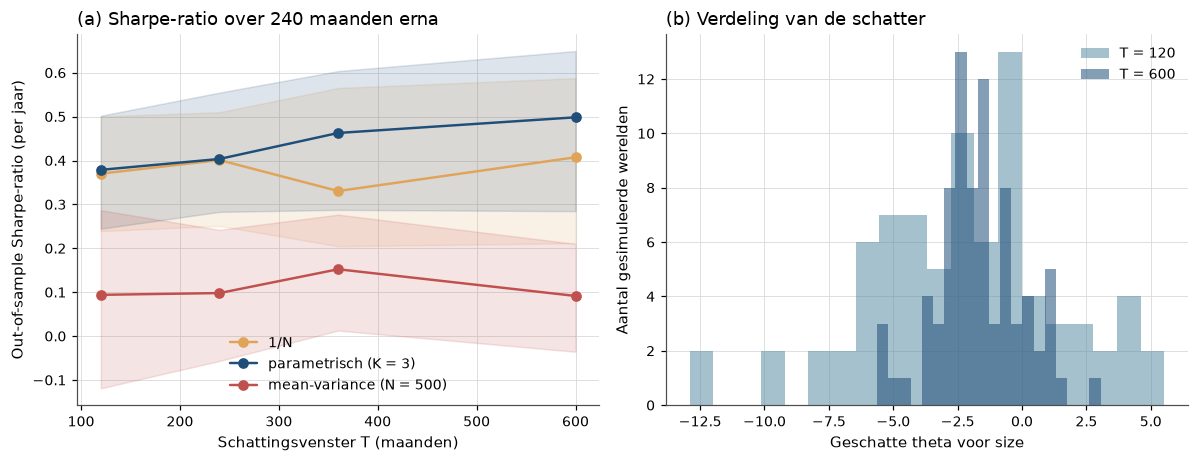

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for col, label, colour in [("SR 1/N", "1/N", hap.plotting.COLORS[3]),
                           ("SR BSV", "parametrisch (K = 3)", hap.plotting.COLORS[0]),
                           ("SR MV", "mean-variance (N = 500)", hap.plotting.COLORS[1])]:
    q = sim.groupby("T")[col].quantile([0.25, 0.5, 0.75]).unstack()
    axes[0].plot(q.index, q[0.5], marker="o", color=colour, label=label)
    axes[0].fill_between(q.index, q[0.25], q[0.75], color=colour, alpha=0.15)
axes[0].set_xlabel("Schattingsvenster T (maanden)")
axes[0].set_ylabel("Out-of-sample Sharpe-ratio (per jaar)")
axes[0].set_title("(a) Sharpe-ratio over 240 maanden erna")
axes[0].legend()
for T, colour in zip((120, 600), (hap.plotting.COLORS[5], hap.plotting.COLORS[0])):
    axes[1].hist(sim.loc[sim["T"] == T, "theta size"], bins=20, alpha=0.55, color=colour, label=f"T = {T}")
axes[1].set_xlabel("Geschatte theta voor size")
axes[1].set_ylabel("Aantal gesimuleerde werelden")
axes[1].set_title("(b) Verdeling van de schatter")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-portfolio-choice-sim-a
:label: fig-portfolio-choice-sim-a
:width: 100%

Links: mediaan en interkwartielafstand van de out-of-sample Sharpe-ratio over
80 gesimuleerde werelden per venster. Mean-variance op 500 gemiddelden
blijft bij elke realistische steekproeflengte ver onder 1/N; de parametrische
policy begint op het niveau van 1/N en loopt weg zodra het venster lang genoeg is
om drie kleine premies te zien. Rechts: de schatter van $\theta$ voor size, ver
van nul af bij vijftig jaar data, maar met een verdeling die bij tien jaar data
nog ruim over nul heen loopt.
:::

De tabel en [](#fig-portfolio-choice-sim-a) laten drie dingen zien. Mean-variance op
500 gemiddelden is kansloos: een mediane Sharpe-ratio tussen 0,09 en 0,15, en een
certainty equivalent tegen de ondergrens van de berekening (−1203% per jaar bij
$T = 120$), omdat de CRRA-belegger in vrijwel elke wereld ergens zijn vermogen verliest —
[](#01-04-markowitz) met $N/T$ tussen 0,8 en 4. De parametrische policy wint niet
vanzelf: bij tien jaar data is haar mediane Sharpe-ratio 0,38 tegen 0,37 voor 1/N, wint
zij in 55% van de werelden en is haar certainty equivalent lager (−2,5% tegen −0,2%), want
de standaarddeviatie van $\hat\theta_{\text{size}}$ is 3,7. Bij vijftig jaar is die 1,7,
de Sharpe-ratio 0,50 tegen 0,41 en het certainty equivalent 0,8% tegen 0,3%. En de
mediaan van 1/N zelf schommelt tussen 0,33 en 0,41: de standaardfout van een
Sharpe-ratio over 240 maanden is ongeveer $\sqrt{12/240} = 0{,}22$. Motief 1 zit in de
hele tabel, ook in de benchmark.

### (b) Gemiddelde variantie zonder informatie

Nu Goyal en Santa-Clara in een wereld waarin hun hypothese per constructie onwaar is. Het
excess marktrendement is i.i.d. (0,6% gemiddeld, 4,5% volatiliteit per maand) en
$\log V_{t+1} = 0{,}74\log V_t + 0{,}50\,\eta_{t+1}$ met
$\Corr(\eta_{t+1}, R^{e}_{m,t+1}) = -0{,}31$, dicht bij wat we hieronder op de 49
industrieportefeuilles meten (0,74; 0,47; −0,31). Elke steekproef heeft 437 maanden
(augustus 1963 – december 1999); we regresseren het cumulatieve rendement over $h$
maanden op $V_t$, met OLS- en Newey-West-standaardfouten.

In [8]:
T_GSC, N_GSC = 437, 5000
PHI_V, SD_V, CORR_RV, MU_M, SD_M = 0.74, 0.50, -0.31, 0.006, 0.045
HORIZONS_GSC = (1, 3, 6, 12)


def simulate_gsc(n_samples, n_months, burn=100):
    """Unpredictable market returns and a persistent log average variance with leverage-type correlation."""
    total = burn + n_months + max(HORIZONS_GSC)
    eps = rng.standard_normal((n_samples, total))
    eta = CORR_RV * eps + np.sqrt(1 - CORR_RV**2) * rng.standard_normal((n_samples, total))
    log_v = signal.lfilter([SD_V], [1, -PHI_V], eta, axis=1)[:, burn:]
    return np.exp(log_v), (MU_M + SD_M * eps)[:, burn:]


def slope_tstats(y, x, lags):
    """Row-wise slope t-values of y on x: OLS and Newey-West with `lags` lags."""  # TODO: naar hap.stats
    xd = x - x.mean(axis=1, keepdims=True)
    sxx = (xd**2).sum(axis=1)
    beta = (xd * y).sum(axis=1) / sxx
    u = y - y.mean(axis=1, keepdims=True) - beta[:, None] * xd
    se_ols = np.sqrt((u**2).sum(axis=1) / (x.shape[1] - 2) / sxx)
    g = xd * u
    s = (g**2).sum(axis=1)
    for j in range(1, lags + 1):
        s += 2 * (1 - j / (lags + 1)) * (g[:, j:] * g[:, :-j]).sum(axis=1)
    return beta / se_ols, beta / (np.sqrt(s) / sxx)


V_sim, r_sim = simulate_gsc(N_GSC, T_GSC)
t_ols, t_nw = {}, {}
for h in HORIZONS_GSC:
    y = np.stack([r_sim[:, t + 1:t + 1 + h].sum(axis=1) for t in range(T_GSC)], axis=1)
    t_ols[h], t_nw[h] = slope_tstats(y, V_sim[:, :T_GSC], lags=h)

reject = pd.DataFrame(
    {"OLS": {h: np.mean(t_ols[h] > 1.96) for h in HORIZONS_GSC},
     "Newey-West (h lags)": {h: np.mean(t_nw[h] > 1.96) for h in HORIZONS_GSC}}
).rename_axis("horizon h (maanden)")
search = np.mean(np.max(np.stack(list(t_ols.values())), axis=0) > 1.96)
print(f"minstens één van de vier OLS-horizonnen 'significant' positief: {search:.1%}")
reject.round(3)

minstens één van de vier OLS-horizonnen 'significant' positief: 25.8%


,OLS,Newey-West (h lags)
horizon h (maanden),,
1,0.028,0.036
3,0.102,0.056
6,0.150,0.062
12,0.188,0.067


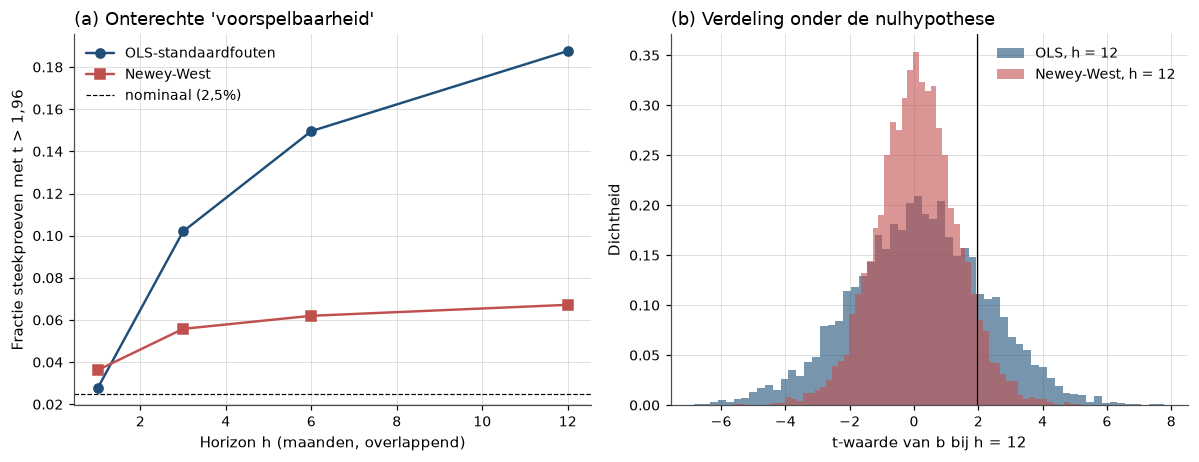

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
axes[0].plot(reject.index, reject["OLS"], marker="o", label="OLS-standaardfouten")
axes[0].plot(reject.index, reject["Newey-West (h lags)"], marker="s", label="Newey-West")
axes[0].axhline(0.025, color="black", lw=0.8, ls="--", label="nominaal (2,5%)")
axes[0].set_xlabel("Horizon h (maanden, overlappend)")
axes[0].set_ylabel("Fractie steekproeven met t > 1,96")
axes[0].set_title("(a) Onterechte 'voorspelbaarheid'")
axes[0].legend()
axes[1].hist(t_ols[12], bins=60, alpha=0.6, density=True, label="OLS, h = 12")
axes[1].hist(t_nw[12], bins=60, alpha=0.6, density=True, label="Newey-West, h = 12")
axes[1].axvline(1.96, color="black", lw=0.8)
axes[1].set_xlabel("t-waarde van b bij h = 12")
axes[1].set_ylabel("Dichtheid")
axes[1].set_title("(b) Verdeling onder de nulhypothese")
axes[1].legend()
fig.tight_layout()
plt.show()

:::{figure} #cel-portfolio-choice-sim-b
:label: fig-portfolio-choice-sim-b
:width: 100%

5000 steekproeven van 437 maanden uit een wereld waarin de gemiddelde variantie
niets voorspelt. Links: bij een horizon van één maand verwerpt de toets ongeveer
zo vaak als hij hoort; met overlappende jaarhorizonnen en gewone standaardfouten
vindt een op de vijf onderzoekers een "significante" positieve helling.
Newey-West haalt het grootste deel van die overdrijving weg, niet alles. Rechts:
de OLS-verdeling is bij $h = 12$ ruim anderhalf keer zo breed als die met Newey-West.
:::

Bij één maand verwerpt de eenzijdige toets in 2,8% (OLS) en 3,6% (Newey-West) van de
steekproeven, dicht bij de nominale 2,5%. Het probleem is de horizon: met overlappende
twaalfmaandsrendementen en OLS-standaardfouten vindt 18,8% een "significant positieve"
helling op een variabele die niets voorspelt, met Newey-West nog 6,7%, en wie de beste van
vier horizonnen rapporteert, vindt in 25,8% van de werelden iets. Goyal en Santa-Clara
zelf rapporteerden maandregressies met Newey-West-$t$-waarden en bootstrap-$p$-waarden —
het deel van de tabel dat zich goed gedraagt.

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Michael Brandt, Pedro Santa-Clara en Rossen Valkanov, *Parametric
Portfolio Policies: Exploiting Characteristics in the Cross-Section of Equity
Returns*, Review of Financial Studies 2009 {cite}`BrandtSantaClaraValkanov2009`.

**Wat.** Hun tabel 1: de lineaire policy met size (log ME),
boek-marktwaarde en momentum, $\gamma = 5$, geschat vanaf januari 1964, met
statistieken over januari 1974 tot december 2002, op "all stocks in the CRSP–Compustat
data set" (gemiddeld 3680 per maand, na weglating van de kleinste 20%). In-sample
$\hat\theta_{\text{me}} = -1{,}451$ (standaardfout 0,548), $\hat\theta_{\text{btm}} =
3{,}606$ (0,921) en $\hat\theta_{\text{mom}} = 1{,}772$ (0,743); Sharpe-ratio 1,048
tegen 0,438 voor de waardegewogen markt; certainty equivalent 17,5% tegen 6,4% per
jaar; een gemiddelde som van negatieve gewichten van −128%, 47% negatieve gewichten en
een omzet van 99% per jaar. Out-of-sample, met elk jaar herschatte $\theta$ op een
groeiende steekproef: Sharpe-ratio 0,941 en certainty equivalent 11,8%. De
long-only-versie (hun tabel 3) haalt in-sample 0,690 en 10,3%, met
$\hat\theta = (-1{,}277;\ 3{,}215;\ 1{,}416)$.

**Data hier.** Individuele aandelen uit CRSP en Compustat zijn niet gratis. We
gebruiken daarom portefeuilles als "activa": de 100 portefeuilles op size en
boek-marktwaarde van French (`hap.data.french("100_Portfolios_10x10")`,
waardegewogen rendementen, aantal firma's, gemiddelde marktkapitalisatie en de
waardegewogen BE/ME per portefeuille), met als karakteristieken log ME, log B/M
en het eigen rendement over maand $t-11$ tot en met $t-1$; en als controle de 25
size-momentumportefeuilles (`"25_Portfolios_ME_Prior_12_2"`) met log ME en het
gemiddelde voorgaande rendement van de aandelen erin. Benchmark: de
waardegewogen portefeuille van dezelfde activa. Risicovrije rente uit
`hap.data.market_monthly()`. $\theta$ geschat op 1964–2002 met $\gamma = 5$,
statistieken over 1974–2002 zoals in het paper; out-of-sample met een elk jaar
herschatte $\theta$ op alle data vanaf 1964, van 1974 tot het einde van de
snapshot, apart gerapporteerd voor 1974–2002 en 2003–2026.

**Verschil met het origineel.** Het paper heeft duizenden aandelen per maand,
wij honderd portefeuilles. Portefeuilles hebben een veel kleinere spreiding in
karakteristieken en veel minder idiosyncratisch risico, en hun karakteristieken
zijn deels de sorteringsvariabele zelf. De momentumkarakteristiek van de
size/BM-portefeuilles is het rendement van de portefeuille, niet het gemiddelde
van haar aandelen. De omzet is bij portefeuilles niet vergelijkbaar met
die bij aandelen, en de samenstelling van de French-portefeuilles wijzigt elk jaar in
juni.

**Verwachte afwijking.** De tekens moeten die van het paper zijn:
$\theta_{\text{size}} < 0$, $\theta_{\text{B/M}} > 0$, $\theta_{\text{mom}} > 0$. In-sample
moet de policy de benchmark duidelijk verslaan in Sharpe-ratio en
certainty equivalent. Out-of-sample verwachten we een kleiner voordeel of
geen: de size- en waardepremie waren na 2002 zwak, en de standaardfout van een
Sharpe-ratio over 23 jaar is ruwweg $\sqrt{1/23} \approx 0{,}21$ per jaar. Een
negatieve $\theta_{\text{B/M}}$ of $\theta_{\text{mom}}$ in-sample betekent een
fout in de code.
```

In [10]:
rf_monthly = hap_data.market_monthly()["RF"]


def load_size_bm():
    """100 size/BM portfolios: returns, total market cap and three characteristics."""
    R = hap_data.french("100_Portfolios_10x10")
    firms = hap_data.french("100_Portfolios_10x10", table=4)
    avg_cap = hap_data.french("100_Portfolios_10x10", table=5)
    bm = hap_data.french("100_Portfolios_10x10", table=6, percent=False)
    chars = {"log ME": np.log(avg_cap.where(avg_cap > 0)),
             "log B/M": np.log(bm.where(bm > 0)),
             "momentum": np.log1p(R).shift(1).rolling(11).sum()}
    return R, firms * avg_cap, chars


def load_size_momentum():
    """25 size/momentum portfolios: returns, total market cap and two characteristics."""
    R = hap_data.french("25_Portfolios_ME_Prior_12_2")
    firms = hap_data.french("25_Portfolios_ME_Prior_12_2", table=4)
    avg_cap = hap_data.french("25_Portfolios_ME_Prior_12_2", table=5)
    prior = hap_data.french("25_Portfolios_ME_Prior_12_2", table=7)
    return R, firms * avg_cap, {"log ME": np.log(avg_cap.where(avg_cap > 0)), "momentum": prior}


def characteristic_panel(R, size, chars, min_assets=10):
    """Month-t characteristics and weights with month-(t+1) returns, standardised per month."""
    nxt = R.shift(-1)
    valid = nxt.notna() & (size > 0)
    for c in chars.values():
        valid &= c.notna()
    n_t = valid.sum(axis=1).to_numpy()
    keep = (n_t >= min_assets) & rf_monthly.reindex(R.index).shift(-1).notna().to_numpy()
    mask = valid.to_numpy()[keep]
    n = n_t[keep].astype(float)

    Z = np.stack([c.to_numpy()[keep] for c in chars.values()], axis=-1)
    Z = np.where(mask[..., None], Z, 0.0)
    mean = Z.sum(axis=1) / n[:, None]
    sd = np.sqrt((np.where(mask[..., None], Z - mean[:, None, :], 0.0) ** 2).sum(axis=1) / (n[:, None] - 1))
    Xs = np.where(mask[..., None], (Z - mean[:, None, :]) / sd[:, None, :], 0.0)

    cap = np.where(mask, size.to_numpy()[keep], 0.0)
    r = np.where(mask, nxt.to_numpy()[keep], 0.0)
    return {"date": pd.DatetimeIndex(R.index.to_series().shift(-1).to_numpy()[keep]),
            "X": Xs, "wbar": cap / cap.sum(axis=1, keepdims=True), "r": r, "n": n,
            "rf": rf_monthly.reindex(R.index).shift(-1).to_numpy()[keep], "names": list(chars)}


def policy_returns(panel):
    """Gross benchmark return and the K characteristic-portfolio returns (eq. rp)."""
    rbar = 1 + (panel["wbar"] * panel["r"]).sum(axis=1)
    rx = np.einsum("tnk,tn->tk", panel["X"], panel["r"]) / panel["n"][:, None]
    return rbar, rx


size_bm = characteristic_panel(*load_size_bm())
size_mom = characteristic_panel(*load_size_momentum())
{name: (p["date"][0].strftime("%Y-%m"), p["date"][-1].strftime("%Y-%m"), round(p["n"].mean(), 1))
 for name, p in [("100 size/BM", size_bm), ("25 size/momentum", size_mom)]}

{'100 size/BM': ('1927-07', '2026-07', np.float64(98.1)),
 '25 size/momentum': ('1927-02', '2026-07', np.float64(25.0))}

Gemiddeld zijn 98 van de 100 size/BM-portefeuilles per maand bruikbaar (niet elke cel is
altijd gevuld); de 25 size-momentumportefeuilles zijn altijd compleet.

In [11]:
def theta_standard_errors(theta, rbar, rx, gamma=GAMMA):
    """Sandwich standard errors G^-1 V G^-1 / T from the proposition."""
    Rp = rbar + rx @ theta
    h = (Rp ** (-gamma))[:, None] * rx
    G = np.einsum("t,tk,tl->kl", -gamma * Rp ** (-gamma - 1), rx, rx) / len(Rp)
    V = h.T @ h / len(Rp)
    G_inv = np.linalg.inv(G)
    return np.sqrt(np.diag(G_inv @ V @ G_inv.T / len(Rp)))


def month_end(month):
    """'2002-12' -> Timestamp('2002-12-31'), so that end months are inclusive."""
    return pd.Timestamp(month) + pd.offsets.MonthEnd(0)


def subset(panel, start, end):
    idx = (panel["date"] >= pd.Timestamp(start)) & (panel["date"] <= month_end(end))
    return {k: (v[idx] if isinstance(v, (np.ndarray, pd.DatetimeIndex)) else v) for k, v in panel.items()}


IN_START, IN_END = "1964-01", "2002-12"
theta_rows = {}
for name, panel in [("100 size/BM", size_bm), ("25 size/momentum", size_mom)]:
    ins = subset(panel, IN_START, IN_END)
    rbar, rx = policy_returns(ins)
    theta = fit_theta(rbar, rx)
    se = theta_standard_errors(theta, rbar, rx)
    for k, char in enumerate(panel["names"]):
        theta_rows[(name, char)] = {"theta": theta[k], "standaardfout": se[k], "t": theta[k] / se[k]}
theta_table = pd.DataFrame(theta_rows).T
theta_table.round(3)

theta  standaardfout      t
100 size/BM      log ME   -1.370          0.762 -1.798
                 log B/M   4.997          0.861  5.801
                 momentum  2.178          0.746  2.918
25 size/momentum log ME   -0.103          0.781 -0.132
                 momentum  2.905          0.698  4.164

De tekens zijn die van het paper en de grootte ligt er dicht bij: op de 100
size/BM-portefeuilles $\hat\theta_{\text{size}} = -1{,}37$ (0,76) tegen −1,451,
$\hat\theta_{\text{B/M}} = 5{,}00$ (0,86) tegen 3,606 en $\hat\theta_{\text{mom}} = 2{,}18$
(0,75) tegen 1,772 — size en momentum binnen een halve standaardfout, B/M 1,6
standaardfout hoger. Na 39 jaar data is size met $t = -1{,}8$ niet op 5% significant,
zoals de simulatie liet verwachten. Op de size-momentumportefeuilles verdwijnt size
($-0{,}10$, standaardfout 0,78) en blijft momentum ($2{,}91$, $t = 4{,}2$).

In [12]:
def weights(panel, theta):
    return panel["wbar"] + np.einsum("tnk,k->tn", panel["X"], theta) / panel["n"][:, None]


def long_only(W):
    W = np.maximum(W, 0.0)
    return W / W.sum(axis=1, keepdims=True)


def fit_theta_long_only(panel, start_theta, gamma=GAMMA):
    """Re-estimate theta with truncated weights (non-smooth, so Nelder-Mead)."""
    def neg_utility(theta):
        Rp = 1 + (long_only(weights(panel, theta)) * panel["r"]).sum(axis=1)
        return -np.mean(Rp ** (1 - gamma)) / (1 - gamma)
    return optimize.minimize(neg_utility, start_theta, method="Nelder-Mead",
                             options={"xatol": 1e-3, "fatol": 1e-8, "maxiter": 2000}).x


def turnover(W, r):
    """Average sum |w_{t+1} - drifted w_t| per month."""
    grown = W[:-1] * (1 + r[:-1])
    drift = grown / grown.sum(axis=1, keepdims=True)
    return np.abs(W[1:] - drift).sum(axis=1).mean()


def evaluate(gross, rf, gamma=GAMMA):
    excess = gross - 1 - rf
    ce = np.mean(gross ** (1 - gamma)) ** (1 / (1 - gamma)) - 1
    return {"gem. excess (% p.j.)": 1200 * excess.mean(), "vol (% p.j.)": 100 * np.sqrt(12) * excess.std(ddof=1),
            "Sharpe (p.j.)": np.sqrt(12) * excess.mean() / excess.std(ddof=1),
            "CE (% p.j.)": 1200 * ce, "SE Sharpe": np.sqrt(12 / len(gross))}


ins = subset(size_bm, IN_START, IN_END)
rbar_in, rx_in = policy_returns(ins)
theta_in = theta_table.loc["100 size/BM", "theta"].to_numpy()
theta_lo = fit_theta_long_only(ins, theta_in)

REPORT_START = "1974-01"                      # BSV report their statistics for 1974-2002
rep = subset(size_bm, REPORT_START, IN_END)
rbar_rep, rx_rep = policy_returns(rep)
W_rep, W_lo_rep = weights(rep, theta_in), long_only(weights(rep, theta_lo))


def weight_stats(W, r):
    return {"som negatieve w": np.minimum(W, 0).sum(axis=1).mean(), "fractie w < 0": (W < 0).mean(),
            "turnover (p.j.)": 12 * turnover(W, r)}


in_sample = pd.DataFrame({
    "VW-benchmark": {**evaluate(rbar_rep, rep["rf"]), **weight_stats(rep["wbar"], rep["r"])},
    "parametrisch": {**evaluate(rbar_rep + rx_rep @ theta_in, rep["rf"]), **weight_stats(W_rep, rep["r"])},
    "parametrisch, long-only": {**evaluate(1 + (W_lo_rep * rep["r"]).sum(axis=1), rep["rf"]),
                                **weight_stats(W_lo_rep, rep["r"])},
}).T
print("theta long-only (1964-2002):", theta_lo.round(3))
in_sample.round(3)

theta long-only (1964-2002): [ 2.381 19.243  5.306]


,gem. excess (% p.j.),vol (% p.j.),Sharpe (p.j.),CE (% p.j.),SE Sharpe,som negatieve w,fractie w < 0,turnover (p.j.)
VW-benchmark,6.352,16.373,0.388,5.688,0.186,0.000,0.000,0.610
parametrisch,24.747,22.385,1.106,19.008,0.186,-1.797,0.388,8.988
"parametrisch, long-only",11.644,17.250,0.675,10.002,0.186,0.000,0.000,1.372


Over 1974–2002 haalt de policy een Sharpe-ratio van 1,11 tegen 0,39 (paper: 1,048
tegen 0,438) en een certainty equivalent van het totale rendement van 19,0% tegen 5,7% per
jaar (paper: 17,5% tegen 6,4%). De positie is extreem: gemiddeld −180% short (paper
−128%), 39% negatieve gewichten (paper 47%) en een omzet van negen keer het vermogen per
jaar (paper 0,99). Die omzet komt vrijwel geheel uit de momentumterm — zonder
$\theta_{\text{mom}}$ is zij 2,8 — omdat het momentum van een portefeuille elke maand
verschuift terwijl haar size en B/M nauwelijks bewegen; ook de benchmark draait door de
jaarlijkse herindeling van de portefeuilles 0,61 per jaar om.

Long-only haalt het grootste deel van de omzet weg: Sharpe-ratio 0,68 (paper 0,690),
certainty equivalent 10,0% (paper 10,3%), omzet 1,4. De long-only-$\hat\theta =
(2{,}38;\ 19{,}24;\ 5{,}31)$ lijkt niet op die van het paper, maar met afgekapte
gewichten is het doel vlak: vier startpunten geven hetzelfde optimum, en het gemiddelde
nut bij de $\theta$ van het paper verschilt pas in de vierde decimaal.

In [13]:
def expanding_oos(panel, start="1974-01", long_only_too=False):
    """Re-estimate theta every January on all data from IN_START until then; return OOS gross returns."""
    rbar, rx = policy_returns(panel)
    out = subset(panel, start, "2100-12")
    years = sorted(set(out["date"].year))
    gross, gross_lo, path = [], [], {}
    for year in years:
        past = (panel["date"] >= pd.Timestamp(IN_START)) & (panel["date"] < pd.Timestamp(f"{year}-01-01"))
        now = panel["date"].year == year
        theta = fit_theta(rbar[past], rx[past])
        path[year] = theta
        gross.append(rbar[now] + rx[now] @ theta)
        if long_only_too:
            sub_past, sub_now = subset(panel, IN_START, f"{year - 1}-12"), subset(panel, f"{year}-01", f"{year}-12")
            th_lo = fit_theta_long_only(sub_past, theta)
            gross_lo.append(1 + (long_only(weights(sub_now, th_lo)) * sub_now["r"]).sum(axis=1))
    result = {"date": out["date"], "policy": np.concatenate(gross), "bench": rbar[panel["date"] >= pd.Timestamp(start)],
              "rf": out["rf"], "theta": pd.DataFrame(path, index=panel["names"]).T}
    if long_only_too:
        result["long_only"] = np.concatenate(gross_lo)
    return result


oos_bm = expanding_oos(size_bm, long_only_too=True)
oos_bm["theta"].iloc[[0, 8, 16, 29, -1]].round(2)

,log ME,log B/M,momentum
1974,-1.13,3.53,3.15
1982,-1.21,4.28,2.22
1990,-1.02,5.18,2.40
2003,-1.37,5.00,2.18
2026,-0.30,2.70,2.38


In [14]:
oos_mom = expanding_oos(size_mom)
oos_parts = {}
for label, (s, e) in {"1974-2002": ("1974-01", "2002-12"), "2003-eind": ("2003-01", "2100-12")}.items():
    for name, res, series in [("100 size/BM", oos_bm, ["bench", "policy", "long_only"]),
                              ("25 size/momentum", oos_mom, ["bench", "policy"])]:
        idx = (res["date"] >= pd.Timestamp(s)) & (res["date"] <= month_end(e))
        for key in series:
            oos_parts[(label, name, {"bench": "VW-benchmark", "policy": "parametrisch",
                                     "long_only": "parametrisch, long-only"}[key])] = evaluate(res[key][idx], res["rf"][idx])
print(f"out-of-sample: {oos_bm['date'][0]:%Y-%m} t/m {oos_bm['date'][-1]:%Y-%m}, {len(oos_bm['date'])} maanden")
pd.DataFrame(oos_parts).T.round(3)

out-of-sample: 1974-01 t/m 2026-07, 631 maanden


gem. excess (% p.j.)  \
1974-2002 100 size/BM      VW-benchmark                            6.352   
                           parametrisch                           22.774   
                           parametrisch, long-only                10.732   
          25 size/momentum VW-benchmark                            6.259   
                           parametrisch                           24.689   
2003-eind 100 size/BM      VW-benchmark                           10.787   
                           parametrisch                           14.399   
                           parametrisch, long-only                11.766   
          25 size/momentum VW-benchmark                           11.098   
                           parametrisch                           11.188   

                                                    vol (% p.j.)  \
1974-2002 100 size/BM      VW-benchmark                   16.373   
                           parametrisch                   22.335   
                           parametrisch, long-only        17.576   
          25 size/momentum VW-benchmark                   16.444   
                           parametrisch                   28.050   
2003-eind 100 size/BM      VW-benchmark                   14.918   
                           parametrisch                   23.105   
                           parametrisch, long-only        18.358   
          25 size/momentum VW-benchmark                   14.977   
                           parametrisch                   17.319   

                                                    Sharpe (p.j.)  \
1974-2002 100 size/BM      VW-benchmark                     0.388   
                           parametrisch                     1.020   
                           parametrisch, long-only          0.611   
          25 size/momentum VW-benchmark                     0.381   
                           parametrisch                     0.880   
2003-eind 100 size/BM      VW-benchmark                     0.723   
                           parametrisch                     0.623   
                           parametrisch, long-only          0.641   
          25 size/momentum VW-benchmark                     0.741   
                           parametrisch                     0.646   

                                                    CE (% p.j.)  SE Sharpe  
1974-2002 100 size/BM      VW-benchmark                   5.688      0.186  
                           parametrisch                  16.270      0.186  
                           parametrisch, long-only        8.579      0.186  
          25 size/momentum VW-benchmark                   5.532      0.186  
                           parametrisch                   6.566      0.186  
2003-eind 100 size/BM      VW-benchmark                   6.620      0.206  
                           parametrisch                   0.941      0.206  
                           parametrisch, long-only        4.274      0.206  
          25 size/momentum VW-benchmark                   6.893      0.206  
                           parametrisch                   4.583      0.206

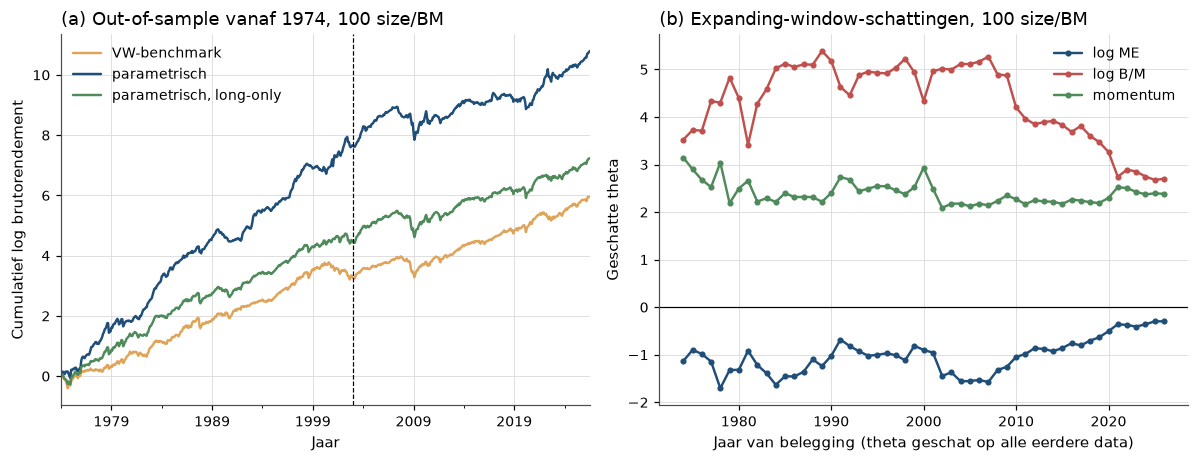

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
wealth = pd.DataFrame({key: np.log(oos_bm[col]).cumsum() for key, col in
                       [("VW-benchmark", "bench"), ("parametrisch", "policy"), ("parametrisch, long-only", "long_only")]},
                      index=oos_bm["date"])
wealth.plot(ax=axes[0], color=[hap.plotting.COLORS[3], hap.plotting.COLORS[0], hap.plotting.COLORS[2]])
axes[0].axvline(pd.Timestamp("2003-01-01"), color="black", lw=0.8, ls="--")
axes[0].set_xlabel("Jaar")
axes[0].set_ylabel("Cumulatief log brutorendement")
axes[0].set_title("(a) Out-of-sample vanaf 1974, 100 size/BM")
oos_bm["theta"].plot(ax=axes[1], marker=".")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Jaar van belegging (theta geschat op alle eerdere data)")
axes[1].set_ylabel("Geschatte theta")
axes[1].set_title("(b) Expanding-window-schattingen, 100 size/BM")
fig.tight_layout()
plt.show()

:::{figure} #cel-portfolio-choice-bsv
:label: fig-portfolio-choice-bsv
:width: 100%

Links: cumulatief log brutorendement vanaf 1974 van de benchmark, de
parametrische policy en de long-only-versie, telkens met een $\theta$ die alleen op
data van 1964 tot het begin van het jaar is geschat. Tot 2003 (stippellijn) loopt de
policy duidelijk weg; daarna niet meer. Rechts: de jaarlijks herschatte $\theta$.
Size blijft tot 2003 tussen −1,0 en −1,4 en kruipt daarna naar −0,30; de
B/M-coëfficiënt loopt op van 3,5 (1974) naar 5,0–5,2 rond 1990–2003 en zakt naar 2,7;
momentum blijft tussen 2,2 en 3,2.
:::

Out-of-sample over 1974–2002 haalt de policy een Sharpe-ratio van 1,02 tegen 0,39 en een
certainty equivalent van 16,3% tegen 5,7% (paper: 0,941 en 11,8%); de
size-momentumpolicy 0,88 tegen 0,38. Na 2002, buiten elke steekproef die het paper kon
zien, draait het teken om: op de 100 size/BM-portefeuilles 0,62 tegen 0,72 en een
certainty equivalent van 0,9% tegen 6,6%, want 23% volatiliteit voor 14% excess
rendement is voor een belegger met $\gamma = 5$ een slechte ruil; long-only 0,64 en 4,3%;
size-momentum 0,65 tegen 0,74. Met een standaardfout van ongeveer 0,21 is geen van die
verschillen van nul te onderscheiden, maar het teken is overal hetzelfde. Dat ligt aan de
rand van wat het replicatieblok verwachtte ("een klein voordeel of geen"): het werd een
klein nadeel.

### Managed portfolios op de markt

```{admonition} Replicatie
:class: seealso

**Bron.** Michael Brandt en Pedro Santa-Clara, *Dynamic Portfolio Selection by
Augmenting the Asset Space*, Journal of Finance 2006 {cite}`BrandtSantaClara2006`.

**Wat.** Hun empirische toepassing in de werkpaperversie (NBER
w10372): aandelen, langlopende staatsobligaties en kasgeld, geconditioneerd op
dividendopbrengst, relatieve T-bill-rente, term spread en default spread, 1945–2000. De
maandelijks herbalancerende conditionele policy haalt volgens de tekst een Sharpe-ratio
van 0,92, "twice that of the unconditional policy of 0.46" (tabel 2 van hetzelfde
werkpaper drukt 0,589 en 0,882 af). Deze getallen konden we niet in het gepubliceerde
artikel controleren.

**Data hier.** Goyal-Welch maanddata via `hap.data.goyal_welch("monthly")`: het
CRSP value-weighted S&P 500-rendement min de T-bill-rente, de log
dividend-prijsratio `dp` en de term spread `tms`, beide op $t$ bekend en
gestandaardiseerd met het gemiddelde en de standaarddeviatie tot dan toe.

**Verschil met het origineel.** Het origineel heeft drie activa, vier
conditioneringsvariabelen en kwadratisch nut met risicoaversie 4; wij hebben één
risicovol activum, twee variabelen, en een in-sampleperiode 1945–2002. Out-of-sample
herschatten we elk jaar vanaf 2003. Wij schatten met CRRA-nut en
$\gamma = 5$ via dezelfde code als de parametrische policy: de managed portfolios
$\mathbf{x}_t \otimes r^{e}_{t+1}$ spelen de rol van $\mathbf{r}^x$, de risicovrije
rente die van de benchmark.

**Verwachte afwijking.** Een positief gewicht op de dividendopbrengst (hoge
opbrengst, meer aandelen) in de naoorlogse steekproef; een klein en onzeker
gewicht op de term spread; en out-of-sample geen of weinig winst ten opzichte
van de statische positie, zoals [](#04-20-voorspelbaarheid) voor dezelfde
voorspellers vond.
```

In [16]:
gw = hap_data.goyal_welch("monthly")
market = pd.DataFrame({"re": (gw["CRSP_SPvw"] - gw["Rfree"]).shift(-1), "rf": gw["Rfree"].shift(-1),
                       "dp": gw["dp"], "tms": gw["tms"]}).dropna()
market["date"] = market.index + pd.offsets.MonthEnd(1)
expanding = market[["dp", "tms"]].expanding(min_periods=120)
z_std = (market[["dp", "tms"]] - expanding.mean()) / expanding.std()
market = market.assign(dp_std=z_std["dp"], tms_std=z_std["tms"]).dropna()


def managed_fit(frame, conditioning):
    """Theta over (constant, conditioning variables) managed market portfolios, CRRA gamma = 5."""
    Z = np.column_stack([np.ones(len(frame)), frame[conditioning].to_numpy()])
    rx = Z * frame["re"].to_numpy()[:, None]
    return fit_theta(1 + frame["rf"].to_numpy(), rx), rx


BSC_START, BSC_END = "1945-01", "2002-12"
bsc_in = market[(market["date"] >= BSC_START) & (market["date"] <= month_end(BSC_END))]
theta_static, _ = managed_fit(bsc_in, [])
theta_dyn, rx_dyn = managed_fit(bsc_in, ["dp_std", "tms_std"])
se_dyn = theta_standard_errors(theta_dyn, 1 + bsc_in["rf"].to_numpy(), rx_dyn)
pd.DataFrame({"statisch": [theta_static[0], np.nan, np.nan], "managed": theta_dyn, "standaardfout": se_dyn},
             index=["markt (constante)", "markt x dp", "markt x tms"]).round(3)

,statisch,managed,standaardfout
markt (constante),0.69,1.131,0.250
markt x dp,NaN,0.452,0.168
markt x tms,NaN,0.322,0.168


In [17]:
def managed_oos(frame, conditioning, start="2003-01"):
    gross = []
    for year in range(int(start[:4]), frame["date"].dt.year.max() + 1):
        past, now = frame[frame["date"] < f"{year}-01-01"], frame[frame["date"].dt.year == year]
        past = past[past["date"] >= BSC_START]
        theta, _ = managed_fit(past, conditioning)
        Z = np.column_stack([np.ones(len(now)), now[conditioning].to_numpy()])
        gross.append(1 + now["rf"].to_numpy() + Z @ theta * now["re"].to_numpy())
    return np.concatenate(gross)


oos_mkt = market[market["date"] >= "2003-01"]
pd.DataFrame({
    "in-sample: statisch": evaluate(1 + bsc_in["rf"].to_numpy() + theta_static[0] * bsc_in["re"].to_numpy(), bsc_in["rf"].to_numpy()),
    "in-sample: managed": evaluate(1 + bsc_in["rf"].to_numpy() + rx_dyn @ theta_dyn, bsc_in["rf"].to_numpy()),
    "out-of-sample: statisch": evaluate(managed_oos(market, []), oos_mkt["rf"].to_numpy()),
    "out-of-sample: managed": evaluate(managed_oos(market, ["dp_std", "tms_std"]), oos_mkt["rf"].to_numpy()),
}).T.round(3)

,gem. excess (% p.j.),vol (% p.j.),Sharpe (p.j.),CE (% p.j.),SE Sharpe
in-sample: statisch,5.246,10.109,0.519,7.258,0.131
in-sample: managed,8.894,13.699,0.649,9.030,0.131
out-of-sample: statisch,7.222,10.338,0.699,6.071,0.209
out-of-sample: managed,5.380,11.105,0.484,3.549,0.209


In-sample (1945–2002) krijgt de dividendopbrengst $\hat\theta_{dp} = 0{,}45$
(standaardfout 0,17) en de term spread 0,32 (0,17), bovenop een constante positie van
1,13. De managed-strategie verhoogt de Sharpe-ratio van 0,52 naar 0,65 en het certainty
equivalent van 7,3% naar 9,0% per jaar. Out-of-sample vanaf 2003 keert het om: 0,48 tegen
0,70, en 3,5% tegen 6,1%. Dat is [](#04-20-voorspelbaarheid) in portefeuillevorm: de
methode lost de schattingsfout in de voorspeller niet op, maar maakt zichtbaar hoeveel
ervan in de gewichten terechtkomt.

### Gemiddelde variantie en het marktrendement

```{admonition} Replicatie
:class: seealso

**Bron.** Amit Goyal en Pedro Santa-Clara, *Idiosyncratic Risk Matters!*,
Journal of Finance 2003 {cite}`GoyalSantaClara2003`.

**Wat.** Hun tabel II: regressies van het maandelijkse
waardegewogen excess marktrendement op de variantie van de vorige maand, augustus 1963 –
december 1999, 437 waarnemingen, met Newey-West-$t$-waarden. De gemiddelde
aandeelvariantie alleen: coëfficiënt 0,336 ($t = 2{,}57$, $\bar R^2 = 1{,}19\%$). De
marktvariantie alleen: −0,597 ($t = -1{,}07$, $\bar R^2 = 0{,}02\%$). Samen: 0,478
($t = 3{,}86$) voor de gemiddelde variantie en −1,449 ($t = -2{,}70$) voor de
marktvariantie, $\bar R^2 = 2{,}17\%$.

**Data hier.** Dagrendementen van de 49 industrieportefeuilles van French
(`hap.data.french("49_Industry_Portfolios", "daily")`) voor de gemiddelde
variantie, dagrendementen van de marktportefeuille (`hap.data.market_daily()`)
voor de marktvariantie, en het maandelijkse excess marktrendement uit
`hap.data.market_monthly()`. Steekproef augustus 1963 – december 1999 en
augustus 1963 – december 2025.

**Verschil met het origineel.** Goyal en Santa-Clara middelen over alle aandelen van
CRSP, wij over 49 industrieën van tientallen tot honderden aandelen. Volgens
[](#eq-portfolio-choice-clmx) en de opmerking erna is het meeste idiosyncratische risico
dan al weggediversifieerd: onze $V_t$ meet industrie-specifieke plus marktvariantie, niet
bedrijfsspecifieke variantie.

**Verwachte afwijking.** Omdat onze $V_t$ weinig idiosyncratisch is, verwachten
we een zwakke of afwezige voorspelling, ook in 1963–1999, en na 1999 niets. Een
sterk significante helling met $t$ boven 3 over de volledige steekproef zou
verrassend zijn en eerst op overlap of uitschieters moeten worden gecontroleerd.
Het aandeel van de afwijkingsterm in $V_t$ moet duidelijk kleiner zijn dan bij
individuele aandelen.
```

In [18]:
industries_daily = hap_data.french("49_Industry_Portfolios", "daily")
market_daily = hap_data.market_daily()["Mkt"]


def monthly_realised_variance(daily):
    """Sum of squared daily returns per calendar month (at least 15 trading days)."""
    month = daily.index.to_period("M")
    variance = (daily**2).groupby(month).sum(min_count=15)
    return variance.set_axis(variance.index.to_timestamp(how="end").normalize())


ind_var = monthly_realised_variance(industries_daily)
ew_index = industries_daily.mean(axis=1)
deviation = monthly_realised_variance(industries_daily.sub(ew_index, axis=0)).mean(axis=1)
gsc = pd.DataFrame({
    "V": ind_var.mean(axis=1),
    "markt": monthly_realised_variance(market_daily),
    "EW-index": monthly_realised_variance(ew_index),
    "afwijking": deviation,
})
gsc["R_e volgende maand"] = hap_data.market_monthly()["Mkt-RF"].shift(-1).reindex(gsc.index)
gsc = gsc.dropna()

periods = {"1963-08 t/m 1999-12": ("1963-08", "1999-12"), "1963-08 t/m 2025-12": ("1963-08", "2025-12"),
           "2000-01 t/m 2025-12": ("2000-01", "2025-12")}
rows = {}
for label, (s, e) in periods.items():
    d = gsc.loc[s:e]
    for spec in (["V"], ["markt"], ["V", "markt"]):
        fit = hap.stats.newey_west(d["R_e volgende maand"], d[spec])
        rows[(label, " + ".join(spec))] = {
            "b (V)": fit.params.get("V", np.nan), "t (V)": fit.tvalues.get("V", np.nan),
            "c (markt)": fit.params.get("markt", np.nan), "t (markt)": fit.tvalues.get("markt", np.nan),
            "R2 (%)": 100 * fit.rsquared, "maanden": int(fit.nobs)}
pd.DataFrame(rows).T.round(3)

b (V)  t (V)  c (markt)  t (markt)  R2 (%)  \
1963-08 t/m 1999-12 V         -0.246 -0.327        NaN        NaN   0.041   
                    markt        NaN    NaN     -0.456     -0.520   0.089   
                    V + markt  1.394  0.519     -2.158     -0.633   0.184   
1963-08 t/m 2025-12 V          0.024  0.038        NaN        NaN   0.001   
                    markt        NaN    NaN     -0.017     -0.020   0.000   
                    V + markt  0.892  0.537     -1.200     -0.525   0.064   
2000-01 t/m 2025-12 V          0.080  0.103        NaN        NaN   0.022   
                    markt        NaN    NaN      0.098      0.092   0.018   
                    V + markt  0.310  0.147     -0.319     -0.107   0.028   

                               maanden  
1963-08 t/m 1999-12 V            437.0  
                    markt        437.0  
                    V + markt    437.0  
1963-08 t/m 2025-12 V            749.0  
                    markt        749.0  
                    V + markt    749.0  
2000-01 t/m 2025-12 V            312.0  
                    markt        312.0  
                    V + markt    312.0

In [19]:
d = gsc.loc["1963-08":"2025-12"]
log_v = np.log(d["V"])
share = (d["afwijking"] / d["V"])
pd.Series({
    "gem. aandeel afwijkingsterm in V, 1963-1999": share.loc[:"1999-12"].mean(),
    "gem. aandeel afwijkingsterm in V, 2000-2025": share.loc["2000-01":].mean(),
    "AR(1) van log V": log_v.autocorr(),
    "SD innovatie log V": (log_v - log_v.autocorr() * log_v.shift(1)).std(),
    "corr(R_e,t , innovatie log V_t)": hap_data.market_monthly()["Mkt-RF"].reindex(d.index).corr(log_v.diff()),
}).round(3)

gem. aandeel afwijkingsterm in V, 1963-1999    0.589
gem. aandeel afwijkingsterm in V, 2000-2025    0.546
AR(1) van log V                                0.741
SD innovatie log V                             0.468
corr(R_e,t , innovatie log V_t)               -0.309
dtype: float64

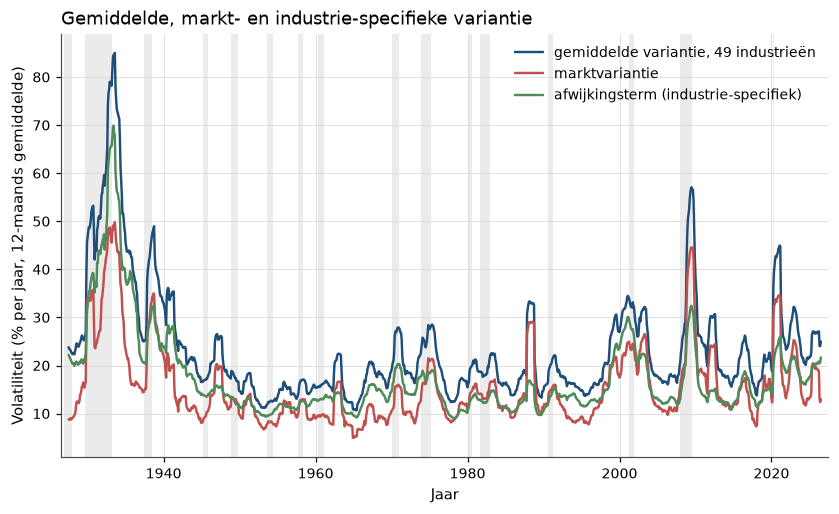

In [20]:
fig, ax = plt.subplots()
annual = lambda s: np.sqrt(12 * s.rolling(12).mean()) * 100
ax.plot(gsc.index, annual(gsc["V"]), label="gemiddelde variantie, 49 industrieën")
ax.plot(gsc.index, annual(gsc["markt"]), label="marktvariantie", color=hap.plotting.COLORS[1])
ax.plot(gsc.index, annual(gsc["afwijking"]), label="afwijkingsterm (industrie-specifiek)", color=hap.plotting.COLORS[2])
hap.plotting.timeline_axis(ax)
hap.plotting.recession_shading(ax)
ax.set_xlabel("Jaar")
ax.set_ylabel("Volatiliteit (% per jaar, 12-maands gemiddelde)")
ax.set_title("Gemiddelde, markt- en industrie-specifieke variantie")
ax.legend()
plt.show()

:::{figure} #cel-portfolio-choice-gsc
:label: fig-portfolio-choice-gsc
:width: 90%

Volatiliteit op jaarbasis, als twaalfmaands voortschrijdend gemiddelde van de
maandvariantie uit dagrendementen, met NBER-recessies in grijs. De gemiddelde variantie
van de 49 industrieën ligt steeds boven die van de markt; de afwijkingsterm (ten
opzichte van het gelijkgewogen gemiddelde van de industrieën) is het industrie-specifieke
deel uit [](#eq-portfolio-choice-clmx). De drie reeksen bewegen grotendeels samen: bij
industrieportefeuilles is het "idiosyncratische" deel voor een groot deel een schaduw
van het marktrisico.
:::

Met industrieportefeuilles is er van het resultaat niets over. Over 1963–1999 is
de helling op $V_t$ alleen −0,25 ($t = -0{,}33$) tegen 0,336 ($t = 2{,}57$) bij Goyal
en Santa-Clara, en de marktvariantie alleen geeft −0,46 ($t = -0{,}52$). Samen hebben
de coëfficiënten wel de tekens van het paper — 1,39 op $V_t$ en −2,16 op de
marktvariantie — maar met $t$-waarden van 0,52 en −0,63. Over de hele steekproef tot
2025 en over 2000–2025 zijn alle $t$-waarden in absolute waarde kleiner dan één. De
afwijkingsterm is gemiddeld 59% van $V_t$ (1963–1999), tegen "almost 85 percent"
idiosyncratisch voor individuele aandelen in het paper; het verschil is de
diversificatie binnen een industrie.

Wat bewijst dat? Weinig, in beide richtingen. Goyal en Santa-Clara gaat het om
bedrijfsspecifieke variantie, en die hebben wij grotendeels weggemiddeld. Wat de
replicatie laat zien, is dat industrie-specifieke onzekerheid niets voorspelt, en dat het
tekenpatroon van de gezamenlijke regressie ook zonder significantie opduikt bij twee
regressoren die voor 0,96 gecorreleerd zijn. Oefening [](#ex-portfolio-choice-3) laat zien
hoe gemakkelijk dezelfde data met overlappende horizonnen wél "significant" worden.

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** De parametrische portefeuille is geen evenwichtstheorie
maar een beslisregel, en als beslisregel doet zij wat Markowitz niet kon: een handvol
feiten omzetten in gewichten zonder dat de schattingsfout van duizenden gemiddelden de
portefeuille overneemt. Op honderd portefeuilles gaf zij de tekens en ruwweg de grootte
van de coëfficiënten van het paper, een in-sample Sharpe-ratio van 1,11 tegen 1,05, en
out-of-sample over 1974–2002 een ruime voorsprong. Het idee van Brandt en Santa-Clara
maakt voorspellers en karakteristieken tot gewone activa; Santa-Clara noemt de policy
"closer to what quantitative managers actually do than anything else in the literature"
{cite}`SantaClara2026`.

**Waar het breekt.** Een parametrische policy is zo goed als de premies die zij uitbuit,
en die zijn slecht gemeten en niet stabiel. Na 2002 haalt de policy op de 100
size/BM-portefeuilles een Sharpe-ratio van 0,62 tegen 0,72 voor de benchmark en een
certainty equivalent van 0,9% tegen 6,6%; op de size-momentumportefeuilles 0,65 tegen
0,74; de managed portfolio op de dividendopbrengst 0,48 tegen 0,70. De methode dempt de
schattingsfout door $N$ tot $K$ terug te brengen, maar zij kan niet zien of de premie van
gisteren morgen nog bestaat. Het tweede spoor brak harder: het resultaat van Goyal en
Santa-Clara hield in latere steekproeven geen stand, en op onze portefeuilledata is er
zelfs in hun eigen periode niets van te zien.

**Risico of vergissing?** Beide feiten laten beide lezingen toe. Chicago: size, waarde
en momentum belonen risico's die het CAPM mist, de policy draagt die met hefboom, en het
certainty equivalent is de vergoeding; de krimp na 2002 is pech of een lagere prijs van
risico. Yale: de karakteristieken meten vergissingen, de policy verdiende aan de
correctie, en na publicatie kopen arbitrageurs die weg. Bij idiosyncratische volatiliteit
is de tegenstelling scherper: in de risicolezing eisen onvolledig gediversifieerde
huishoudens een premie en is CIV een beprijsde toestandsvariabele; in de vergissingslezing
worden volatiele aandelen als loten overgewaardeerd en renderen ze daarom slecht. Wat de
lezingen zou scheiden — of de rendementen samenhangen met marginaal nut in slechte tijden
— is met portefeuilledata niet te meten. Santa-Clara's praktijkmotief laat de vraag over
die elke belegger met zo'n policy moet stellen: draagt zij beprijsd risico, of denkt zij
iets te weten wat de prijs niet weet?

**Wat er daarna kwam.** In 2008 bleek dat de hefboom waarmee zulke strategieën worden
uitgevoerd van intermediairs komt, en dat hun balans zelf een beprijsde factor is: zie
[](#05-32-intermediaries).

## Oefeningen

:::{exercise}
:label: ex-portfolio-choice-1

**De mean-variance-benadering van de parametrische policy.** Laat
$R_p = \bar R + \boldsymbol{\theta}'\mathbf{r}^x$.

1. Leid [](#eq-portfolio-choice-mv) af door $\E[R_p] - \tfrac{\gamma}{2}\Var(R_p)$ te
   maximaliseren.
2. Laat zien dat bij kwadratisch nut in het tweede moment,
   $\E[R_p - 1] - \tfrac{\gamma}{2}\E[(R_p-1)^2]$, de oplossing
   $\boldsymbol{\theta} = \E[\mathbf{r}^x\mathbf{r}^{x\prime}]^{-1}\big(\gamma^{-1}\boldsymbol{\mu}_x - \E[\mathbf{r}^x(\bar R - 1)]\big)$
   is, en dat dit met $\bar R = 1$ precies [](#eq-portfolio-choice-bsc-theta) is.
3. Bereken $\boldsymbol{\theta}^{\mathrm{mv}}$ op de in-sampledata van de 100
   size/BM-portefeuilles en vergelijk met de CRRA-schatting. Waar komt het verschil vandaan?
:::

:::{solution} ex-portfolio-choice-1
:class: dropdown

**(1)** $\E[R_p] = \E[\bar R] + \boldsymbol{\theta}'\boldsymbol{\mu}_x$ en
$\Var(R_p) = \Var(\bar R) + 2\boldsymbol{\theta}'\Cov(\mathbf{r}^x, \bar R) + \boldsymbol{\theta}'\boldsymbol{\Sigma}_x\boldsymbol{\theta}$.
De afgeleide naar $\boldsymbol{\theta}$ is
$\boldsymbol{\mu}_x - \gamma\Cov(\mathbf{r}^x, \bar R) - \gamma\boldsymbol{\Sigma}_x\boldsymbol{\theta}$;
nul stellen geeft [](#eq-portfolio-choice-mv). **(2)** Dezelfde stap met
$\E[(R_p - 1)^2] = \E[(\bar R-1)^2] + 2\boldsymbol{\theta}'\E[\mathbf{r}^x(\bar R-1)] + \boldsymbol{\theta}'\E[\mathbf{r}^x\mathbf{r}^{x\prime}]\boldsymbol{\theta}$.
Met $\bar R = 1$ (de benchmark is de risicovrije rente, in excess-termen nul) valt
de middelste term weg.

In [21]:
Sigma_x = np.cov(rx_in, rowvar=False)
cov_bench = np.array([np.cov(rx_in[:, k], rbar_in)[0, 1] for k in range(rx_in.shape[1])])
theta_mv = np.linalg.solve(Sigma_x, rx_in.mean(axis=0) / GAMMA - cov_bench)
pd.DataFrame({"CRRA": theta_in, "mean-variance": theta_mv}, index=size_bm["names"]).round(3)

,CRRA,mean-variance
log ME,-1.370,-1.181
log B/M,4.997,4.640
momentum,2.178,2.472


**(3)** De mean-variance-benadering geeft $(-1{,}18;\ 4{,}64;\ 2{,}47)$ tegen
$(-1{,}37;\ 5{,}00;\ 2{,}18)$ met CRRA-nut: dezelfde tekens en ordegrootte. Het verschil
komt uit de hogere momenten die CRRA-nut wel ziet: de karakteristiekportefeuilles zijn
scheef en dikstaartig, en een belegger met $\gamma = 5$ straft een linkerstaart zwaarder
af dan de variantie doet. Momentum, met de crashes uit [](#04-19-momentum), krijgt bij
CRRA daarom een kleiner gewicht. De oefening laat zien dat de parametrische policy in de
kern een Markowitz-probleem in drie activa is, met een correctie voor staartrisico.
:::

:::{exercise}
:label: ex-portfolio-choice-2

**Transactiekosten.** Neem de out-of-sample parametrische policy op de 100
size/BM-portefeuilles.

1. Bereken voor elke maand de omzet $\sum_i |w_{i,t+1} - w^{\mathrm{drift}}_{i,t}|$ van
   de policy en van de benchmark.
2. Trek kosten van $c \in \{0;\ 0{,}25;\ 0{,}5;\ 1\}\%$ per eenheid omzet af en
   rapporteer Sharpe-ratio en certainty equivalent.
3. Bij welke $c$ is de policy out-of-sample (1974 tot nu) niet meer beter dan de
   benchmark? Wat zegt dat over een schatter die kosten negeert?
:::

:::{solution} ex-portfolio-choice-2
:class: dropdown

In [22]:
def turnover_series(W, r):
    grown = W[:-1] * (1 + r[:-1])
    return np.r_[0.0, np.abs(W[1:] - grown / grown.sum(axis=1, keepdims=True)).sum(axis=1)]


def net_of_costs(panel, theta, cost):
    W = weights(panel, theta)
    gross = 1 + (W * panel["r"]).sum(axis=1)
    bench = 1 + (panel["wbar"] * panel["r"]).sum(axis=1)
    return (gross - cost * turnover_series(W, panel["r"]),
            bench - cost * turnover_series(panel["wbar"], panel["r"]))


oos_panel = subset(size_bm, "1974-01", "2100-12")
theta_oos_path = oos_bm["theta"].reindex(oos_panel["date"].year).to_numpy()
W_oos = oos_panel["wbar"] + np.einsum("tnk,tk->tn", oos_panel["X"], theta_oos_path) / oos_panel["n"][:, None]
turn_policy = turnover_series(W_oos, oos_panel["r"])
turn_bench = turnover_series(oos_panel["wbar"], oos_panel["r"])


def oos_sharpe_gap(c):
    """OOS Sharpe ratio of the policy minus that of the benchmark, both net of costs c."""
    net = 1 + (W_oos * oos_panel["r"]).sum(axis=1) - c * turn_policy
    bench = 1 + (oos_panel["wbar"] * oos_panel["r"]).sum(axis=1) - c * turn_bench
    return evaluate(net, oos_panel["rf"])["Sharpe (p.j.)"] - evaluate(bench, oos_panel["rf"])["Sharpe (p.j.)"]


cost_rows = {}
for c in (0.0, 0.0025, 0.005, 0.01):
    gross_in, bench_in = net_of_costs(ins, theta_in, c)
    net_oos = 1 + (W_oos * oos_panel["r"]).sum(axis=1) - c * turnover_series(W_oos, oos_panel["r"])
    cost_rows[f"c = {100 * c:.2f}%"] = {
        "Sharpe in-sample policy": evaluate(gross_in, ins["rf"])["Sharpe (p.j.)"],
        "Sharpe in-sample benchmark": evaluate(bench_in, ins["rf"])["Sharpe (p.j.)"],
        "Sharpe OOS policy": evaluate(net_oos, oos_panel["rf"])["Sharpe (p.j.)"],
        "Sharpe OOS benchmark": evaluate(net_oos, oos_panel["rf"])["Sharpe (p.j.)"] - oos_sharpe_gap(c),
        "CE OOS policy (% p.j.)": evaluate(net_oos, oos_panel["rf"])["CE (% p.j.)"]}
print(f"gem. omzet per maand: policy {turn_policy.mean():.3f}, benchmark {turn_bench.mean():.3f}")
print(f"break-evenkosten out-of-sample: {100 * optimize.brentq(oos_sharpe_gap, 0.0, 0.05):.2f}% per eenheid omzet")
pd.DataFrame(cost_rows).T.round(3)

gem. omzet per maand: policy 0.810, benchmark 0.048
break-evenkosten out-of-sample: 0.79% per eenheid omzet


,Sharpe in-sample policy,Sharpe in-sample benchmark,Sharpe OOS policy,Sharpe OOS benchmark,CE OOS policy (% p.j.)
c = 0.00%,1.062,0.328,0.838,0.530,9.275
c = 0.25%,0.964,0.318,0.731,0.521,6.813
c = 0.50%,0.866,0.308,0.624,0.511,4.348
c = 1.00%,0.670,0.288,0.410,0.493,-0.589


De policy zet gemiddeld 0,81 van haar vermogen per maand om, de benchmark 0,048.
In-sample (1964–2002) blijft de policy bij elke kostenpost ruim boven de benchmark: bij 1%
per eenheid omzet is de Sharpe-ratio 0,67 tegen 0,29. Out-of-sample vanaf 1974 is de
voorsprong zonder kosten 0,84 tegen 0,53; zij verdwijnt bij 0,79% per eenheid omzet, en
bij 1% is het certainty equivalent negatief. Een schatter die kosten negeert, kiest $\theta$ alsof omzet gratis is; daarom nemen
Brandt, Santa-Clara en Valkanov de kosten op in het doel zelf.
:::

:::{exercise}
:label: ex-portfolio-choice-3

**Overlap op echte data.** Herhaal de regressie van Goyal en Santa-Clara over
1963–1999 met de cumulatieve excess marktrendementen over $h \in \{1, 3, 6, 12\}$
maanden als afhankelijke variabele en $V_t$ als enige regressor.

1. Rapporteer de $t$-waarde met OLS- en met Newey-West-standaardfouten ($h$ lags).
2. Vergelijk de verhouding tussen de twee met de simulatie hierboven.
3. Wat moet een onderzoeker die in 2003 alleen de 12-maandsregressie met
   OLS-standaardfouten rapporteert volgens de simulatie als "significant"
   beschouwen?
:::

:::{solution} ex-portfolio-choice-3
:class: dropdown

In [23]:
d = gsc.loc["1963-08":"1999-12"]
r_next = hap_data.market_monthly()["Mkt-RF"]
overlap_rows = {}
for h in HORIZONS_GSC:
    cumulative = r_next.rolling(h).sum().shift(-h).reindex(d.index)
    frame = pd.concat([cumulative.rename("y"), d["V"]], axis=1).dropna()
    t_o, t_n = slope_tstats(frame["y"].to_numpy()[None, :], frame["V"].to_numpy()[None, :], lags=h)
    overlap_rows[h] = {"t OLS": float(t_o[0]), "t Newey-West": float(t_n[0]),
                       "verhouding": float(t_o[0] / t_n[0])}
sim_ratio = {h: np.median(np.abs(t_ols[h]) / np.abs(t_nw[h])) for h in HORIZONS_GSC}
pd.DataFrame(overlap_rows).T.assign(**{"verhouding in simulatie (mediaan)": pd.Series(sim_ratio)}).round(3)

,t OLS,t Newey-West,verhouding,verhouding in simulatie (mediaan)
1,-0.425,-0.303,1.401,0.951
3,2.444,1.599,1.528,1.254
6,2.700,1.533,1.761,1.481
12,1.828,1.241,1.473,1.685


Bij één maand is er niets: $t = -0{,}43$ met OLS en $-0{,}30$ met Newey-West. Bij
drie en zes maanden geeft OLS 2,44 en 2,70 — twee keer "significant" — en Newey-West 1,60
en 1,53. De verhouding tussen de twee $t$-waarden (1,5 tot 1,8 bij $h \geq 3$) ligt in de
buurt van wat de simulatie voor dezelfde horizonnen geeft (mediaan 1,25 tot 1,69). Een
onderzoeker die in 2003 alleen de twaalfmaandsregressie met OLS had gerapporteerd, had
$t = 1{,}83$ gevonden — een waarde die volgens de simulatie niets bewijst.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->